In [1]:
import os
import glob
import pandas as pd
import numpy as np
import logging
#import esmvalcore.preprocessor
import xarray as xr
from xmip.preprocessing import rename_cmip6
import matplotlib.path as mpath
import matplotlib.pyplot as plt
import cftime
from scipy import stats
import seaborn as sns
import warnings
from tqdm import tqdm
warnings.filterwarnings('ignore')
import matplotlib
matplotlib.rcParams.update({'font.size': 15})
import dask
from utils import Utils

lat_band_dict = {'Tropics':[-23, 23], 
                 'Arctic':[66, 91],
                 'Antarctic':[-91, -66],
                 'Global':[-91, 91]}

### set up read-in for MH's 1.5C runs:

MH_run_archive = '/gws/ssde/j25b/moghli/MH_runs/'



MH_EQ_runs = ['u-de029', 'u-de034', 'u-cy805']
MH_15_runs = ['u-cu743', 'u-cy806', 'u-cy807']
MH_30_runs = ['u-cr991', 'u-cs992', 'u-cs993', 'u-cs994', 'u-cs995']
MH_60_runs = ['u-ct762', 'u-cy808', 'u-cy809']

MH_inj_loc_dict = {'EQ':MH_EQ_runs,
                   '15':MH_15_runs,
                   '30':MH_30_runs,
                   '60':MH_60_runs,
                   }

SAI_runs = {'de029':'EQ',
            'de034':'EQ',
            'cy805':'EQ',
            'cu743':'15',
            'cy806':'15',
            'cy807':'15',
            'cr991':'30',
            'cs992':'30',
            'cs993':'30',
            'cs994':'30',
            'cs995':'30',
            'ct762':'60',
            'cy808':'60',
            'cy809':'60'
           }

In [2]:

def read_in(dir, ocean = False):
    files = []
    for x in os.listdir(dir):
        files.append(dir + x)
    with dask.config.set(**{'array.slicing.split_large_chunks': True}):
        ds = rename_cmip6(xr.open_mfdataset(files, use_cftime=True, engine='netcdf4'))
    return ds

def read_in_ens_mean(dirs, ocean = False, zonal_mean=False, max_ens_members=False):
    """ returns (1) the ensemble mean dataset, and (2) the number of ensemble members """
    
    files = []
    if max_ens_members:
        dirs = dirs[0:max_ens_members]
    for dir in dirs:
        for x in os.listdir(dir):
            if '.nc' in x:
                files.append(dir + x)
    with dask.config.set(**{'array.slicing.split_large_chunks': True}):
        ds = rename_cmip6(xr.open_mfdataset(files, use_cftime=True, concat_dim='ensemble',combine='nested'))
        n_ens = len(ds.ensemble) 
        ds = ds.mean(dim='ensemble')
        if zonal_mean:
            ds = ds.mean(dim='x')
        ds['number_ens_mems_meaned'] = n_ens
    return ds


def get_gmst(ds):
    return calc_spatial_mean(ds.tas.mean(dim="time"), lon_name="x", lat_name="y").values

def get_dirs(var, model, scenario, table='Amon'):
    if scenario == 'ARISE':
        dirs = glob.glob('/badc/deposited2022/arise/data/ARISE/MOHC/UKESM1-0-LL/arise-sai-1p5/*/{t}/{v}/*/*/'.format(
            t=table, v=var))
    else:
        dirs = glob.glob('/badc/cmip6/data/CMIP6/*/*/{m}/{s}/*/{t}/{v}/*/latest/'.format(
            m=model, s=scenario, t=table, v=var))
    weird_jasmin_vars = ['rlds', 'rlus'] 
    if model == 'UKESM1-0-LL': # weird error on opening several files, perhaps corrupted?
        if var == 'rlds':
            dirs = dirs[0:2]
        if var == 'rlus':
            dirs = dirs[1:]
    return dirs



def get_all_vars_arctic_monthly(vars, model, scenario,
                                min_lat, max_lat,
                                min_year, max_year):
    ds_list = []
    for var in tqdm(vars):
        ds = read_in_ens_mean(get_dirs(var, model, scenario, table='Amon'),
                              ocean=False, zonal_mean=True,
                              max_ens_members=5)
        ds_list.append(ds)
    
    DS = xr.merge(ds_list, compat='override')
    
    ## take an arctic spatial mean:
    DS = DS.sel(y=slice(min_lat, max_lat))
    weights = np.cos(np.deg2rad(DS.y))
    weights.name = "weights"
    DS_weighted = DS.weighted(weights)
    DS_smean = DS_weighted.mean("y")
    
    ## take late-century monthly time-mean
    DS_stmean = DS_smean.sel(time=slice(min_year, max_year)).groupby("time.month").mean(dim="time")
    
    return DS_stmean

def get_surface_area_north_of_lat(min_lat):
    path = '/badc/cmip6/data/CMIP6/CMIP/MOHC/UKESM1-0-LL/piControl/r1i1p1f2/fx/areacella/gn/latest/areacella_fx_UKESM1-0-LL_piControl_r1i1p1f2_gn.nc'
    areacella = rename_cmip6(xr.open_dataset(path))
    out = areacella.sel(y=slice(min_lat, 90.1)).sum(dim=['x', 'y']).areacella.values*1
    return out


##### SETTINGS
model = 'UKESM1-0-LL'
min_lat, max_lat = 66, 90
min_year_late_cent, max_year_late_cent = "2050", "2070"


do_preprocess = False

In [3]:
### define set of required variables

rad_flux_vars_surface = ['rsds', 'rsus', 'rlds', 'rlus', 'rsdscs', 'rldscs']
# all radiative vars at surface

rad_flux_vars_TOA = ['rsdt', 'rsut', 'rlut']
# all radiative vars at top-of-atmosphere

heat_flux_vars_surface = ['hfls', 'hfss'] 
# surface upward latent heat flux and surface upward sensible heat flux

PE_vars = ['pr']

AHT_vars = ['tas'] + rad_flux_vars_surface + rad_flux_vars_TOA + heat_flux_vars_surface + PE_vars


In [4]:
variable_rename_dict = {'surface_downwelling_shortwave_flux_in_air':'rsds',
                        'surface_downwelling_shortwave_flux_in_air_assuming_clear_sky':'rsdscs',
                        'surface_net_downward_shortwave_flux':'rsns',
                        'surface_upwelling_shortwave_flux_in_air_assuming_clear_sky':'rsuscs',
                        'toa_incoming_shortwave_flux':'rsdt',
                        'toa_outgoing_longwave_flux':'rlut',
                        'toa_outgoing_longwave_flux_assuming_clear_sky':'rlutcs',
                        'toa_outgoing_shortwave_flux':'rsut',
                        'toa_outgoing_shortwave_flux_assuming_clear_sky':'rsutcs',
                        'precipitation_flux':'pr', 
                        'surface_downwelling_longwave_flux_in_air':'rlds',
                        'surface_downwelling_longwave_flux_in_air_assuming_clear_sky':'rldscs',
                        'surface_net_downward_longwave_flux':'rlns',
                        'surface_upward_latent_heat_flux':'hfls',
                        'surface_upward_sensible_heat_flux':'hfss',
                        'air_temperature':'tas'}

In [5]:
def get_MH_run_Qvars(run):
    ds1 = xr.open_dataset('/gws/ssde/j25b/moghli/MH_runs/u-{r}/{r}_ali2.nc'.format(r=run))
    ds1 = ds1[['precipitation_flux', 
             'surface_downwelling_longwave_flux_in_air', 
             'surface_downwelling_longwave_flux_in_air_assuming_clear_sky',
             'surface_net_downward_longwave_flux',
             'surface_upward_latent_heat_flux',
             'surface_upward_sensible_heat_flux']]
    
    ds2 = xr.open_dataset('/gws/ssde/j25b/moghli/MH_runs/u-{r}/UKESM1_u-{r}.nc'.format(r=run))
    ds3 =  xr.open_dataset('/gws/ssde/j25b/moghli/MH_runs/u-{r}/ukesm_u-{r}_small.nc'.format(r=run))['air_temperature']
    ds = xr.merge([ds2, ds1, ds3])
    ds = ds.rename(variable_rename_dict)
    ds = ds.rename({'latitude':'y', 'longitude':'x'})
    ds['rsus'] = ds['rsds'] - ds['rsns']
    ds['rlus'] = ds['rlds'] - ds['rlns']
    ds = ds[AHT_vars]
    ds = ds.mean('x')
    ds.load()
    # and take the arctic time mean:
    ds_arctic = ds.sel(y=slice(min_lat, max_lat))
    weights = np.cos(np.deg2rad(ds_arctic.y))
    weights.name = "weights"
    ds_arctic_weighted = ds_arctic.weighted(weights)
    ds_arctic_smean = ds_arctic_weighted.mean("y")

    ## take late-century monthly time-mean
    ds = ds_arctic_smean.sel(time=slice(min_year_late_cent, max_year_late_cent)).groupby("time.month").mean(dim="time")

    return ds

In [6]:
### preproces, a couple minutes:
scenarios = ['ssp245']


if do_preprocess:
    for scen in scenarios:
        ds = get_all_vars_arctic_monthly(vars=AHT_vars, model=model,
                                          scenario=scen,
                                          min_lat=min_lat, max_lat=max_lat,
                                          min_year=min_year_late_cent, max_year=max_year_late_cent)
        ds = ds.compute()
        ds.to_netcdf('../Preprocessed_data/{s}_{l}_{m}.nc'.format(
            s=scen, l=str(min_lat), m=model))

ds_ssp245 = xr.open_dataset('../Preprocessed_data/{s}_{l}_{m}.nc'.format(
        s='ssp245', l=str(min_lat), m=model))

In [7]:
xr.open_dataset('../Preprocessed_data/{s}_{l}_{m}.nc'.format(
        s='ssp245', l=str(min_lat), m=model))

<xarray.Dataset> Size: 6kB
Dimensions:                 (month: 12, bnds: 2, plev: 19)
Coordinates:
    height                  float64 8B ...
  * plev                    (plev) float64 152B 1e+05 9.25e+04 ... 500.0 100.0
  * month                   (month) int64 96B 1 2 3 4 5 6 7 8 9 10 11 12
Dimensions without coordinates: bnds
Data variables: (12/19)
    lat_bounds              (month, bnds) float64 192B ...
    lon_bounds              (month, bnds) float64 192B ...
    tas                     (month) float64 96B ...
    number_ens_mems_meaned  (month) float64 96B ...
    rsds                    (month) float64 96B ...
    rsus                    (month) float64 96B ...
    ...                      ...
    hfls                    (month) float64 96B ...
    hfss                    (month) float64 96B ...
    evspsbl                 (month) float64 96B ...
    pr                      (month) float64 96B ...
    ta                      (month, plev) float64 2kB ...
    hus                     (month, plev) float64 2kB ...

In [8]:
#ds.to_netcdf('../Preprocessed_data//{s}_{y1}-{y2}_{l}_{m}.nc'.format(
#            s=scen, y1=min_year_pd, y2=max_year_pd, l=str(min_lat), m=model))

In [9]:
#also preprocess a present day version of ssp245:
scen = 'ssp245'
min_year_pd = '2015'
max_year_pd = '2033'
ds = get_all_vars_arctic_monthly(vars=AHT_vars, model=model,
                                          scenario=scen,
                                          min_lat=min_lat, max_lat=max_lat,
                                          min_year=min_year_pd, max_year=max_year_pd)
ds = ds.compute()
ds.to_netcdf('../Preprocessed_data//{s}_{y1}-{y2}_{l}_{m}.nc'.format(
            s=scen, y1=min_year_pd, y2=max_year_pd, l=str(min_lat), m=model))

100%|██████████| 13/13 [00:18<00:00,  1.39s/it]


### Atmospheric heat Transport

Define a quantity, Q, as the residual from all energy budget terms above, for the pan-Arctic atmospheric column.

Q is equal to the sum of (1) AHT across boundary, and (2) change in energy stored in atmospheric column. 

or in my notation:

Q = AHT + d(S)/dt 

where S is the atmospheric stored energy, is equal to the integral over pressure levels of delta(cT + Lq)

In [10]:

# take Q as sum of energy leaving air column 
def get_Q(ds, units='W/m2'):
    
    if not units in ['W/m2', 'PW']: #check units
        print('Units must be set to either "W/m2" or "PW", default is W/m2') 
        
    ds = ds.mean('month')
    Q = (ds.rsds - ds.rsus + ds.rlds - ds.rlus - ds.hfls - ds.hfss + ds.rsut - ds.rsdt + ds.rlut)
   
    ### need to multiply by area to get these into total AHT units (PW)
    area = get_surface_area_north_of_lat(min_lat)
    unit_conversions = {'W/m2':1,
                        'PW':area/(10**15)}
    ### now split into moist and dry components. Done following Hahn et al. 2021
    ### https://www.frontiersin.org/articles/10.3389/feart.2021.710036/full
    ### we take moist energy transport as (P-E)*(latent heat of vaporisation).
    ### this neglects the latent heat of fusion for solid precip. 
    ### the dry component is then calculated as the difference between Q and moist

    L = 2.501*(10**6)# latent heat of vaporisation, assumed constant at 2.501 × 10^6 J kg−1
    Qmoist = (ds.pr - ds.evspsbl)*L 

    Q = Q*unit_conversions[units] 
    Qmoist = Qmoist*unit_conversions[units]
        
    Qdry = Q - Qmoist
    return {'Q':Q.values*1, 'Qdry':Qdry.values*1, 'Qmoist':Qmoist.values*1}

def get_monthlyQ(ds, units='W/m2'):

    if not units in ['W/m2', 'PW']: #check units
        print('Units must be set to either "W/m2" or "PW", default is W/m2') 
    
    ### need to multiply by area to get these into total AHT units (PW)
    area = get_surface_area_north_of_lat(min_lat)
    unit_conversions = {'W/m2':1,
                        'PW':area/(10**15)}
    ds['Q'] = (ds.rsds - ds.rsus + ds.rlds - ds.rlus - ds.hfls - ds.hfss + ds.rsut - ds.rsdt + ds.rlut)*unit_conversions[units] #in PW

    ### now split into moist and dry components. Done following Hahn et al. 2021
    ### https://www.frontiersin.org/articles/10.3389/feart.2021.710036/full
    ### we take moist energy transport as (P-E)*(latent heat of vaporisation).
    ### this neglects the latent heat of fusion for solid precip. 
    ### the dry component is then calculated as the difference between Q and moist

    L = 2.501*(10**6)# latent heat of vaporisation, assumed constant at 2.501 × 10^6 J kg−1
    ### OLD VERSION, which used evspsbl:  ###  ds['Qmoist'] = (ds.pr - ds.evspsbl)*L*unit_conversions[units]  
    ## new, uses hfls instead:
    ds['Qmoist'] = ds.pr*L*unit_conversions[units] - ds.hfls 
    ds['Qdry'] = ds['Q'] - ds['Qmoist']
    return ds

units = 'W/m2'

# add heat transport to ds's
Q_ssp245 = get_Q(ds_ssp245, units=units)
ds_ssp245 = get_monthlyQ(ds_ssp245, units=units)    


In [11]:
ds_ssp245_base =xr.open_dataset('../Preprocessed_data//{s}_{y1}-{y2}_{l}_{m}.nc'.format(s=scen, y1=min_year_pd, y2=max_year_pd, l=str(min_lat), m=model))
ds_ssp245_base = get_monthlyQ(ds_ssp245_base, units=units)    


In [12]:
ds_ssp245_base

<xarray.Dataset> Size: 2kB
Dimensions:                 (month: 12, bnds: 2)
Coordinates:
    height                  float64 8B ...
  * month                   (month) int64 96B 1 2 3 4 5 6 7 8 9 10 11 12
Dimensions without coordinates: bnds
Data variables: (12/19)
    lat_bounds              (month, bnds) float64 192B ...
    lon_bounds              (month, bnds) float64 192B ...
    tas                     (month) float64 96B ...
    number_ens_mems_meaned  (month) float64 96B ...
    rsds                    (month) float64 96B ...
    rsus                    (month) float64 96B ...
    ...                      ...
    hfls                    (month) float64 96B ...
    hfss                    (month) float64 96B ...
    pr                      (month) float64 96B 1.059e-05 ... 1.148e-05
    Q                       (month) float64 96B 116.7 115.1 99.4 ... 122.3 117.5
    Qmoist                  (month) float64 96B 14.92 14.78 14.8 ... 18.46 15.78
    Qdry                    (month) float64 96B 101.8 100.3 ... 103.8 101.8

In [13]:
ds_list, runs = [], []
for run in SAI_runs.keys():
    print(run)
    runs.append(run)
    ds_list.append(get_monthlyQ(get_MH_run_Qvars(run), units=units))

ds_dict_sai = dict(zip(runs, ds_list))

de029
de034
cy805
cu743
cy806
cy807
cr991
cs992
cs993
cs994
cs995
ct762
cy808
cy809


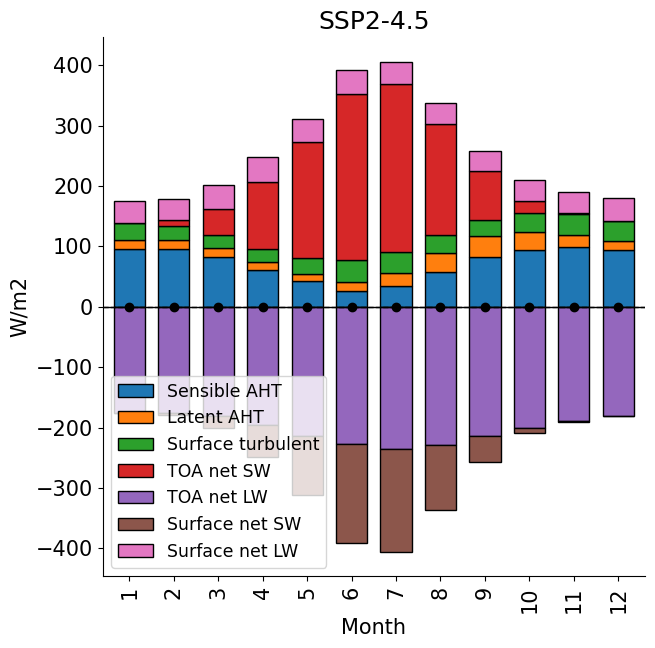

In [14]:
ds_dict = {'SSP2-4.5':ds_ssp245,
          }
    
    
fig, ax = plt.subplots(1, len(ds_dict), figsize = (7, 7))#, sharey=True)
    
i=0
for title in ds_dict:
    ds = ds_dict[title]
    
    #ax = axs[i]
    #ax = axs
    df = pd.DataFrame({'Month':ds.month.values,
                       'tas':ds.tas.values,
                   'Total HT':ds.Q.values + ds.hfls.values + ds.hfss.values - ds.rsut.values + ds.rsdt.values - ds.rlut.values - ds.rsds.values + ds.rsus.values - ds.rlds.values + ds.rlus.values,
                   'Sensible AHT':ds.Qdry.values,
                   'Latent AHT':ds.Qmoist.values,
                    'Surface turbulent':ds.hfls.values + ds.hfss.values,
                       'TOA net SW': -ds.rsut.values + ds.rsdt.values,
                       'TOA net LW': -ds.rlut.values,
                       'Surface net SW':-ds.rsds.values + ds.rsus.values,
                       'Surface net LW':-ds.rlds.values + ds.rlus.values,
                   #'OHT':ds.hfAtl_66.values 
                   }
                 )#.set_index('Month')
    mean = df['Total HT'].mean()
    df.drop(columns=['Total HT', 'tas']).plot(kind = "bar",
            x='Month',
            stacked = True,
            ax = ax,
            width = 0.7,
            edgecolor = "black")
    
    ax.scatter(range(len(df)), df['Total HT'], c='black')
    #ax.plot(range(len(df)), df['tas'], c='red', ls='--')
    ax.set_title(title)
    if i == 0:   
        ax.set_ylabel(units)
    ax.axhline(y=0, c='black', lw=1)
    ax.axhline(y=mean, c='black', lw=1, ls='--')
    ax.spines['right'].set_visible(False)
    ax.spines['top'].set_visible(False)
    ax.legend(fontsize='small', loc='lower left')
    if i > 0:
        ax.get_legend().remove()
        
    i=i+1
#plt.savefig('Figures/main/atmospheric_column_budget_detailed_SSP245.jpg', dpi=400)

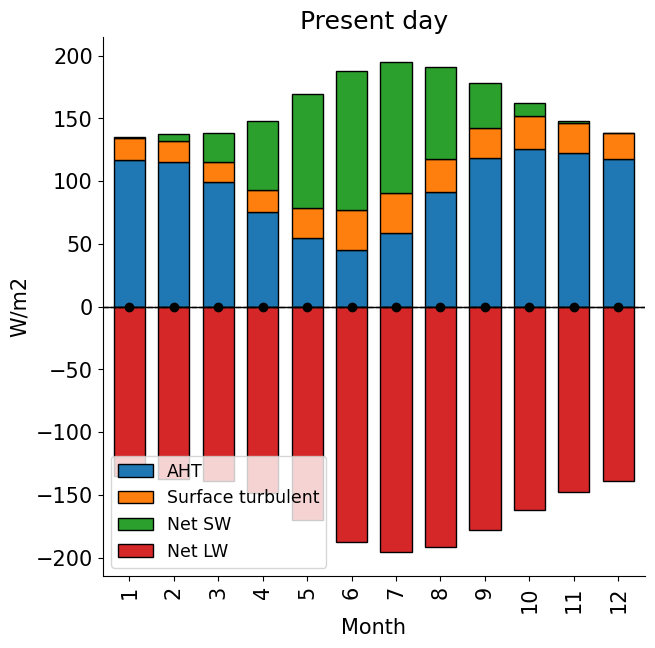

In [15]:
ds_dict = {'Present day':ds_ssp245_base,
          }
    
    
fig, ax = plt.subplots(1, len(ds_dict), figsize = (7, 7))#, sharey=True)
    
i=0
for title in ds_dict:
    ds = ds_dict[title]
    
    #ax = axs[i]
    #ax = axs
    df = pd.DataFrame({'Month':ds.month.values,
                       'tas':ds.tas.values,
                   'Total HT':ds.Q.values + ds.hfls.values + ds.hfss.values - ds.rsut.values + ds.rsdt.values - ds.rlut.values - ds.rsds.values + ds.rsus.values - ds.rlds.values + ds.rlus.values,
                   'AHT':ds.Qdry.values + ds.Qmoist.values,
                    'Surface turbulent':ds.hfls.values + ds.hfss.values,
                    'Net SW': (-ds.rsut.values + ds.rsdt.values - ds.rsds.values + ds.rsus.values),
                      'Net LW': (-ds.rlut.values - ds.rlds.values + ds.rlus.values),
                   #'OHT':ds.hfAtl_66.values 
                   }
                 )#.set_index('Month')
    mean = df['Total HT'].mean()
    df.drop(columns=['Total HT', 'tas']).plot(kind = "bar",
            x='Month',
            stacked = True,
            ax = ax,
            width = 0.7,
            edgecolor = "black")
    
    ax.scatter(range(len(df)), df['Total HT'], c='black')
    #ax.plot(range(len(df)), df['tas'], c='red', ls='--')
    ax.set_title(title)
    if i == 0:   
        ax.set_ylabel(units)
    ax.axhline(y=0, c='black', lw=1)
    ax.axhline(y=mean, c='black', lw=1, ls='--')
    ax.spines['right'].set_visible(False)
    ax.spines['top'].set_visible(False)
    ax.legend(fontsize='small', loc='lower left')
    if i > 0:
        ax.get_legend().remove()
        
    i=i+1
#plt.savefig('Figures/baseline_simple_budget.jpg', dpi=350, bbox_inches='tight')

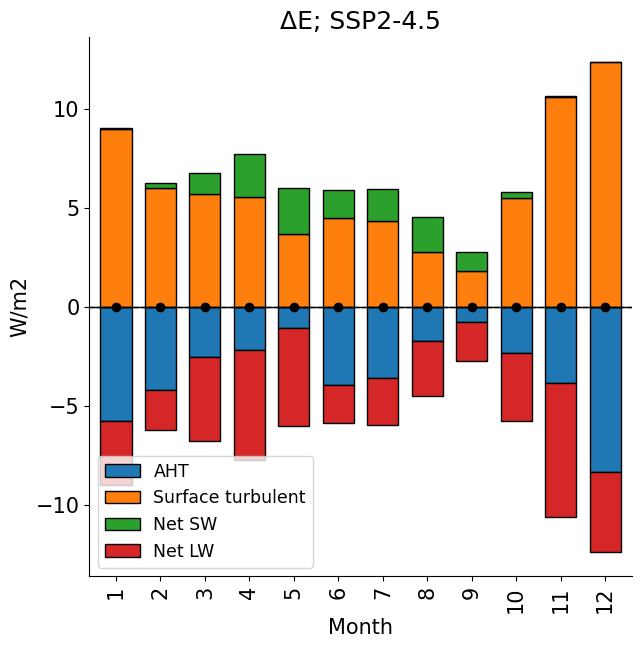

In [16]:
ds_dict = {'\u0394E; SSP2-4.5':ds_ssp245-ds_ssp245_base,
          }
    
    
fig, ax = plt.subplots(1, len(ds_dict), figsize = (7, 7))#, sharey=True)
    
i=0
for title in ds_dict:
    ds = ds_dict[title]
    
    #ax = axs[i]
    #ax = axs
    df = pd.DataFrame({'Month':ds.month.values,
                       'tas':ds.tas.values,
                   'Total HT':ds.Q.values + ds.hfls.values + ds.hfss.values - ds.rsut.values + ds.rsdt.values - ds.rlut.values - ds.rsds.values + ds.rsus.values - ds.rlds.values + ds.rlus.values,
                   'AHT':ds.Qdry.values + ds.Qmoist.values,
                    'Surface turbulent':ds.hfls.values + ds.hfss.values,
                    'Net SW': (-ds.rsut.values + ds.rsdt.values - ds.rsds.values + ds.rsus.values),
                      'Net LW': (-ds.rlut.values - ds.rlds.values + ds.rlus.values),
                   #'OHT':ds.hfAtl_66.values 
                   }
                 )#.set_index('Month')
    mean = df['Total HT'].mean()
    df.drop(columns=['Total HT', 'tas']).plot(kind = "bar",
            x='Month',
            stacked = True,
            ax = ax,
            width = 0.7,
            edgecolor = "black")
    
    ax.scatter(range(len(df)), df['Total HT'], c='black')
    #ax.plot(range(len(df)), df['tas'], c='red', ls='--')
    ax.set_title(title)
    if i == 0:   
        ax.set_ylabel(units)
    ax.axhline(y=0, c='black', lw=1)
    ax.axhline(y=mean, c='black', lw=1, ls='--')
    ax.spines['right'].set_visible(False)
    ax.spines['top'].set_visible(False)
    ax.legend(fontsize='small', loc='lower left')
    if i > 0:
        ax.get_legend().remove()
        
    i=i+1
#plt.savefig('Figures/SSP245_perturbation_simple.jpg', dpi=400, bbox_inches='tight')

In [17]:
# slightly slow
ds_EQ = xr.concat([ds_dict_sai[r.split('-')[1]] for r in MH_EQ_runs], dim='Ensemble_member')
ds_15 = xr.concat([ds_dict_sai[r.split('-')[1]] for r in MH_15_runs], dim='Ensemble_member')
ds_30 = xr.concat([ds_dict_sai[r.split('-')[1]] for r in MH_30_runs], dim='Ensemble_member')
ds_60 = xr.concat([ds_dict_sai[r.split('-')[1]] for r in MH_60_runs], dim='Ensemble_member')

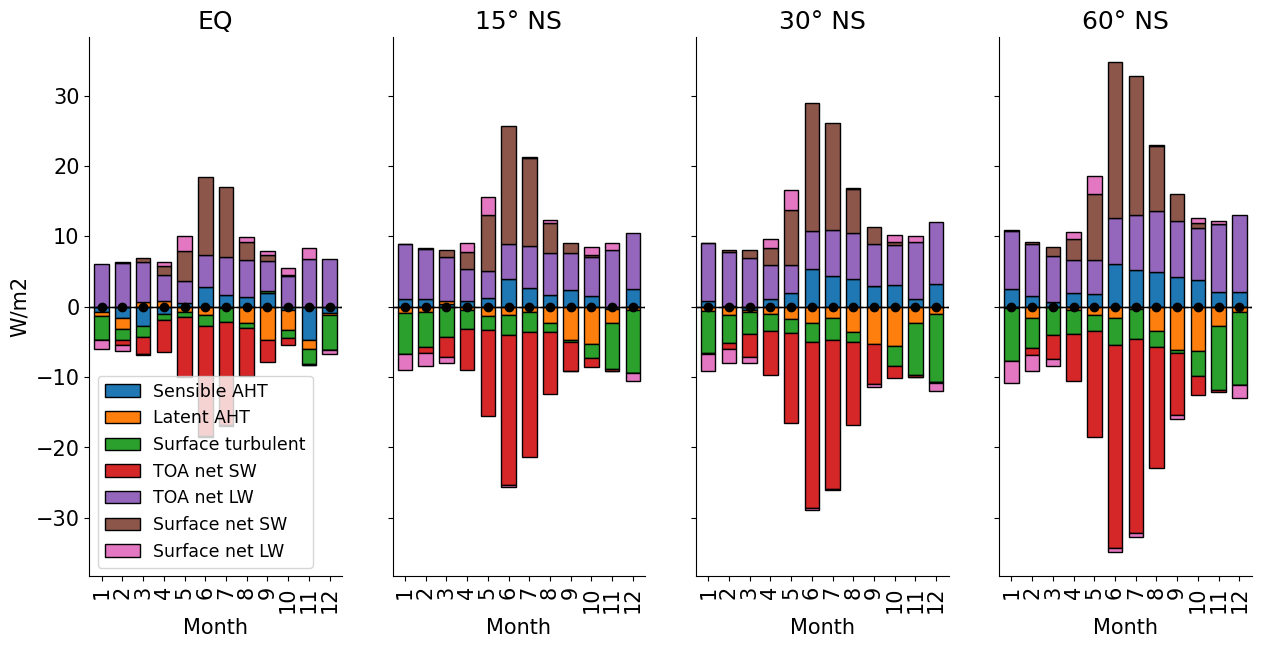

In [18]:
ds_dict = {'EQ':ds_EQ.mean('Ensemble_member') - ds_ssp245,
           '15° NS':ds_15.mean('Ensemble_member') - ds_ssp245,
           '30° NS':ds_30.mean('Ensemble_member') - ds_ssp245,
           '60° NS':ds_60.mean('Ensemble_member') - ds_ssp245,
           
          }
    
    
fig, axs = plt.subplots(1, len(ds_dict), figsize = (15, 7), sharey=True)
    
i=0
for title in ds_dict:
    ds = ds_dict[title]
    
    ax = axs[i]
    #ax = axs
    df = pd.DataFrame({'Month':ds.month.values,
                       #'tas':ds.tas.values,
                   'Total HT':ds.Q.values + ds.hfls.values + ds.hfss.values - ds.rsut.values + ds.rsdt.values - ds.rlut.values - ds.rsds.values + ds.rsus.values - ds.rlds.values + ds.rlus.values,
                   'Sensible AHT':ds.Qdry.values,
                   'Latent AHT':ds.Qmoist.values,
                    'Surface turbulent':ds.hfls.values + ds.hfss.values,
                       'TOA net SW': -ds.rsut.values + ds.rsdt.values,
                       'TOA net LW': -ds.rlut.values,
                       'Surface net SW':-ds.rsds.values + ds.rsus.values,
                       'Surface net LW':-ds.rlds.values + ds.rlus.values,
                   #'OHT':ds.hfAtl_66.values 
                   }
                 )#.set_index('Month')
    mean = df['Total HT'].mean()
    df.drop(columns=['Total HT']).plot(kind = "bar",
            x='Month',
            stacked = True,
            ax = ax,
            width = 0.7,
            edgecolor = "black")
    
    ax.scatter(range(len(df)), df['Total HT'], c='black')
    #ax.plot(range(len(df)), df['tas'], c='red', ls='--')
    ax.set_title(title)
    if i == 0:   
        ax.set_ylabel(units)
    ax.axhline(y=0, c='black', lw=1)
    ax.axhline(y=mean, c='black', lw=1, ls='--')
    ax.spines['right'].set_visible(False)
    ax.spines['top'].set_visible(False)
    ax.legend(fontsize='small', loc='lower left')
    if i > 0:
        ax.get_legend().remove()
        
    i=i+1
#plt.savefig('Figures/main/atmospheric_column_budget_detailed_SSP245.jpg', dpi=400)

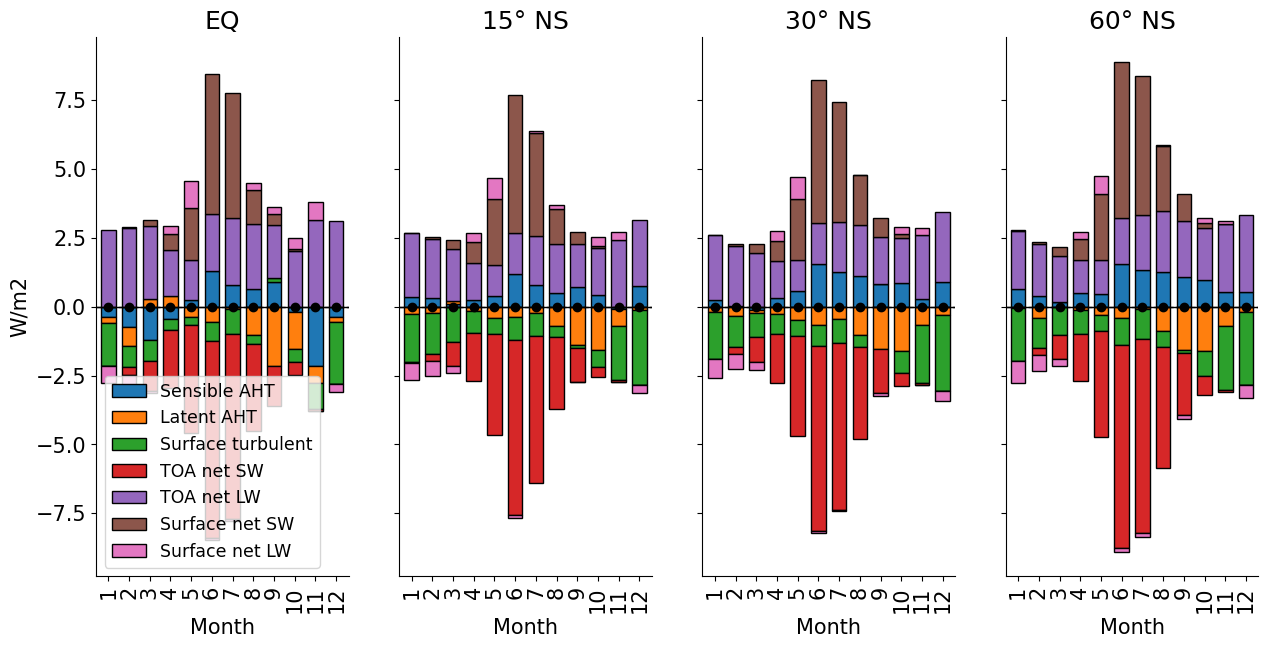

In [19]:
ds_dict = {'EQ':ds_EQ.mean('Ensemble_member') - ds_ssp245,
           '15° NS':ds_15.mean('Ensemble_member') - ds_ssp245,
           '30° NS':ds_30.mean('Ensemble_member') - ds_ssp245,
           '60° NS':ds_60.mean('Ensemble_member') - ds_ssp245,
           
          }
    
    
fig, axs = plt.subplots(1, len(ds_dict), figsize = (15, 7), sharey=True)
    
i=0
for title in ds_dict:
    ds = ds_dict[title]
    arctic_cooling = -ds.tas.mean().item()
    ax = axs[i]
    #ax = axs
    df = pd.DataFrame({'Month':ds.month.values,
                       #'tas':ds.tas.values,
                   'Total HT':(ds.Q.values + ds.hfls.values + ds.hfss.values - ds.rsut.values + ds.rsdt.values - ds.rlut.values - ds.rsds.values + ds.rsus.values - ds.rlds.values + ds.rlus.values)/arctic_cooling,
                   'Sensible AHT':(ds.Qdry.values)/arctic_cooling,
                   'Latent AHT':(ds.Qmoist.values)/arctic_cooling,
                    'Surface turbulent':(ds.hfls.values + ds.hfss.values)/arctic_cooling,
                       'TOA net SW': (-ds.rsut.values + ds.rsdt.values)/arctic_cooling,
                       'TOA net LW': (-ds.rlut.values)/arctic_cooling,
                       'Surface net SW':(-ds.rsds.values + ds.rsus.values)/arctic_cooling,
                       'Surface net LW':(-ds.rlds.values + ds.rlus.values)/arctic_cooling,
                   #'OHT':ds.hfAtl_66.values 
                   }
                 )#.set_index('Month')
    mean = df['Total HT'].mean()
    df.drop(columns=['Total HT']).plot(kind = "bar",
            x='Month',
            stacked = True,
            ax = ax,
            width = 0.7,
            edgecolor = "black")
    
    ax.scatter(range(len(df)), df['Total HT'], c='black')
    #ax.plot(range(len(df)), df['tas'], c='red', ls='--')
    ax.set_title(title)
    if i == 0:   
        ax.set_ylabel(units)
    ax.axhline(y=0, c='black', lw=1)
    ax.axhline(y=mean, c='black', lw=1, ls='--')
    ax.spines['right'].set_visible(False)
    ax.spines['top'].set_visible(False)
    ax.legend(fontsize='small', loc='lower left')
    if i > 0:
        ax.get_legend().remove()
        
    i=i+1
#plt.savefig('Figures/main/atmospheric_column_budget_detailed_SSP245.jpg', dpi=400)

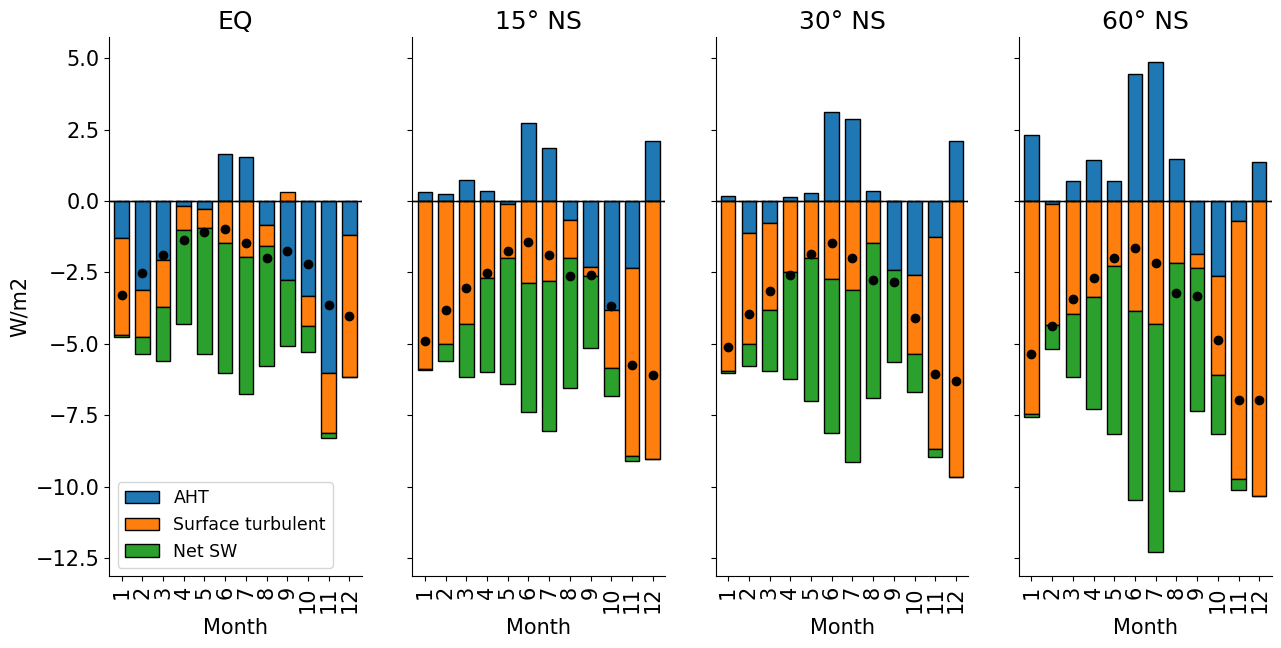

In [20]:
ds_dict = {'EQ':ds_EQ.mean('Ensemble_member') - ds_ssp245,
           '15° NS':ds_15.mean('Ensemble_member') - ds_ssp245,
           '30° NS':ds_30.mean('Ensemble_member') - ds_ssp245,
           '60° NS':ds_60.mean('Ensemble_member') - ds_ssp245,
           
          }
    
    
fig, axs = plt.subplots(1, len(ds_dict), figsize = (15, 7), sharey=True)
    
i=0
for title in ds_dict:
    ds = ds_dict[title]
    
    ax = axs[i]
    #ax = axs
    df = pd.DataFrame({'Month':ds.month.values,
                       'tas':ds.tas.values,
                       'Total HT':(ds.Q.values + ds.hfls.values + ds.hfss.values - ds.rsut.values + ds.rsdt.values - ds.rlut.values - ds.rsds.values + ds.rsus.values - ds.rlds.values + ds.rlus.values),
                       'AHT':(ds.Qdry.values+ds.Qmoist.values),
                       #'Latent AHT':ds.Qmoist.values,
                        'Surface turbulent':(ds.hfls.values + ds.hfss.values),
                       'Net SW': (-ds.rsut.values + ds.rsdt.values - ds.rsds.values + ds.rsus.values),
                      
                   }
                 )#.set_index('Month')
    mean = df['Total HT'].mean()
    df.drop(columns=['Total HT', 'tas']).plot(kind = "bar",
            x='Month',
            stacked = True,
            ax = ax,
            width = 0.7,
            edgecolor = "black")
    
    ax.scatter(range(len(df)), df['tas'], c='black')
    #ax.plot(range(len(df)), df['tas'], c='red', ls='--')
    ax.set_title(title)
    if i == 0:   
        ax.set_ylabel(units)
    ax.axhline(y=0, c='black', lw=1)
    ax.axhline(y=mean, c='black', lw=1, ls='--')
    ax.spines['right'].set_visible(False)
    ax.spines['top'].set_visible(False)
    ax.legend(fontsize='small', loc='lower left')
    if i > 0:
        ax.get_legend().remove()
        
    i=i+1
#plt.savefig('Figures/atmospheric_column_budget_all.jpg', dpi=400)

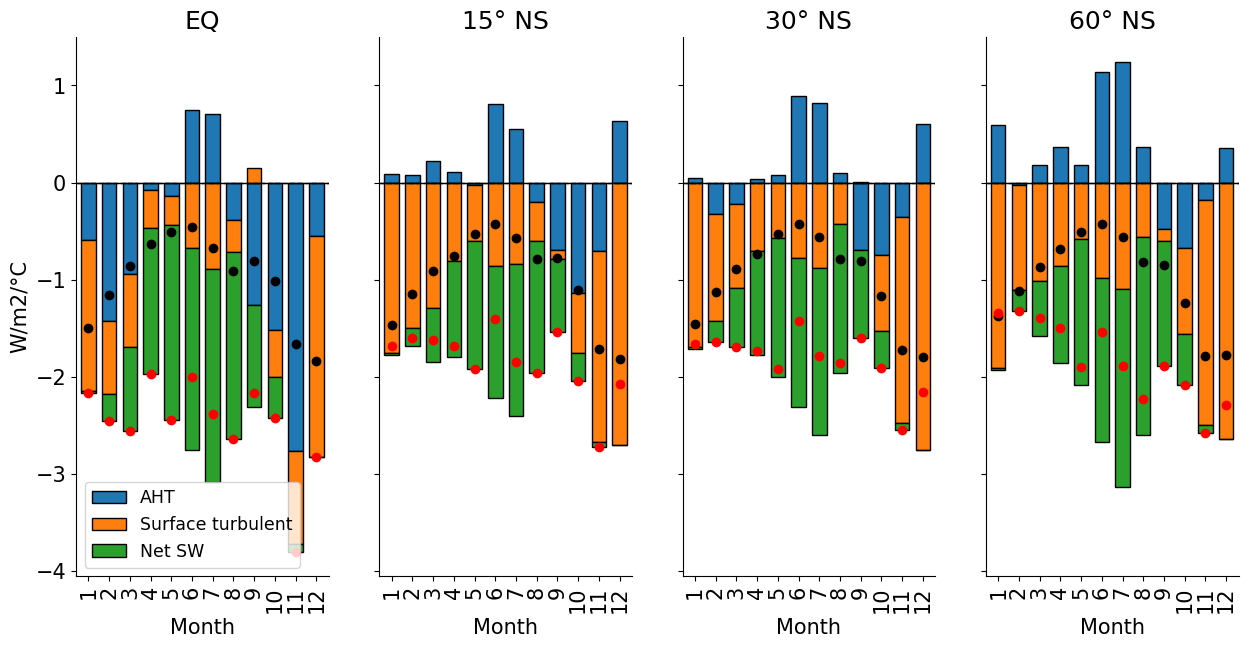

In [21]:
## now normalise by annual mean arctic cooling

ds_dict = {'EQ':ds_EQ.mean('Ensemble_member') - ds_ssp245,
           '15° NS':ds_15.mean('Ensemble_member') - ds_ssp245,
           '30° NS':ds_30.mean('Ensemble_member') - ds_ssp245,
           '60° NS':ds_60.mean('Ensemble_member') - ds_ssp245,
           
          }
    
    
fig, axs = plt.subplots(1, len(ds_dict), figsize = (15, 7), sharey=True)
    
i=0
for title in ds_dict:
    ds = ds_dict[title]
    arctic_cooling = -ds.tas.mean().item()
    ax = axs[i]
    #ax = axs
    df = pd.DataFrame({'Month':ds.month.values,
                       'tas':ds.tas.values/arctic_cooling,
                       'Total HT':(ds.Q.values + ds.hfls.values + ds.hfss.values - ds.rsut.values + ds.rsdt.values - ds.rlut.values - ds.rsds.values + ds.rsus.values - ds.rlds.values + ds.rlus.values)/arctic_cooling,
                       'AHT':(ds.Qdry.values+ds.Qmoist.values)/arctic_cooling,
                       #'Latent AHT':ds.Qmoist.values,
                        'Surface turbulent':(ds.hfls.values + ds.hfss.values)/arctic_cooling,
                       'Net SW': (-ds.rsut.values + ds.rsdt.values - ds.rsds.values + ds.rsus.values)/arctic_cooling,
                      
                   }
                 )#.set_index('Month')
    mean = df['Total HT'].mean()
    df.drop(columns=['Total HT', 'tas']).plot(kind = "bar",
            x='Month',
            stacked = True,
            ax = ax,
            width = 0.7,
            edgecolor = "black")
    
    ax.scatter(range(len(df)), df['tas'], c='black')
    ax.scatter(range(len(df)), df['Net SW'] + df['Surface turbulent']+df['AHT'], c='red')
    
    #ax.plot(range(len(df)), df['tas'], c='red', ls='--')
    ax.set_title(title)
    if i == 0:   
        ax.set_ylabel(units+'/°C')
    ax.axhline(y=0, c='black', lw=1)
    ax.axhline(y=mean, c='black', lw=1, ls='--')
    ax.spines['right'].set_visible(False)
    ax.spines['top'].set_visible(False)
    ax.legend(fontsize='small', loc='lower left')
    if i > 0:
        ax.get_legend().remove()
        
    i=i+1
#plt.savefig('Figures/main/atmospheric_column_budget_detailed_SSP245.jpg', dpi=400)

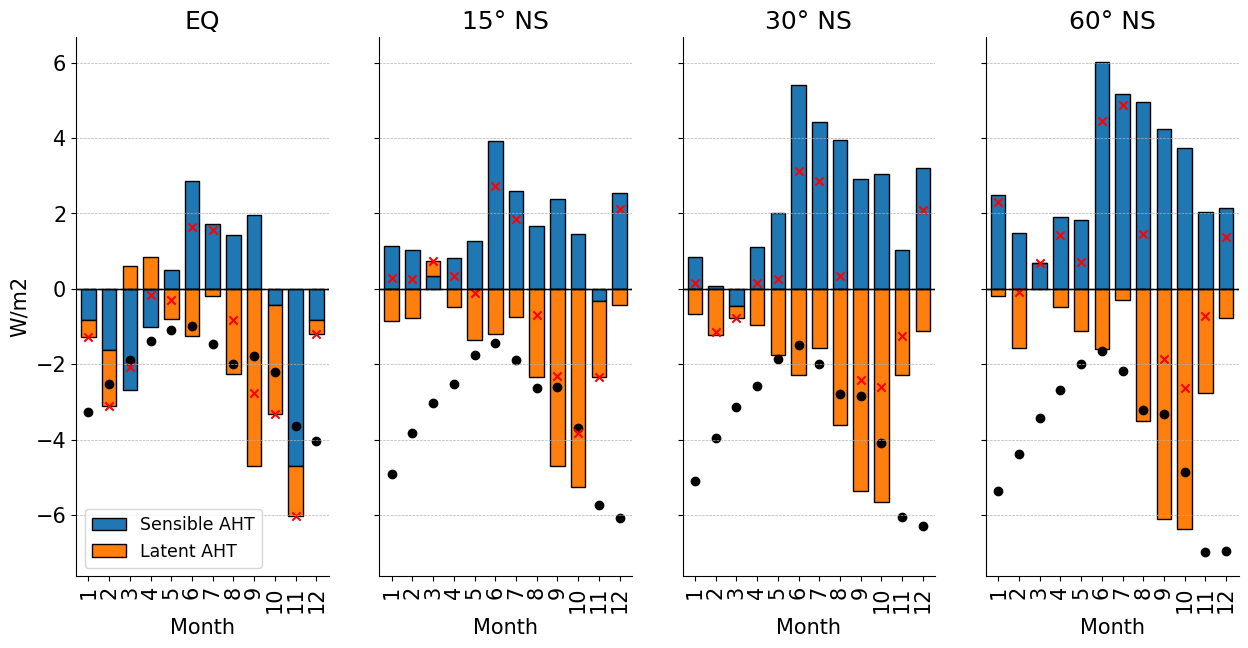

In [22]:
## add a plot of sensible and latent heat transports poleward, as functions of (1) global mean temperature anomaly, and (2) meridional tempetature gradient

## now normalise by annual mean arctic cooling

ds_dict = {'EQ':ds_EQ.mean('Ensemble_member') - ds_ssp245,
           '15° NS':ds_15.mean('Ensemble_member') - ds_ssp245,
           '30° NS':ds_30.mean('Ensemble_member') - ds_ssp245,
           '60° NS':ds_60.mean('Ensemble_member') - ds_ssp245,
           
          }
    
    
fig, axs = plt.subplots(1, len(ds_dict), figsize = (15, 7), sharey=True)
    
i=0
for title in ds_dict:
    ds = ds_dict[title]
    arctic_cooling = -ds.tas.mean().item()
    ax = axs[i]
    #ax = axs
    df = pd.DataFrame({'Month':ds.month.values,
                       'tas':ds.tas.values,
                       'Total HT':(ds.Q.values + ds.hfls.values + ds.hfss.values - ds.rsut.values + ds.rsdt.values - ds.rlut.values - ds.rsds.values + ds.rsus.values - ds.rlds.values + ds.rlus.values),
                       'AHT':(ds.Qdry.values+ds.Qmoist.values),
                       'Sensible AHT':ds.Qdry.values,
                       'Latent AHT':ds.Qmoist.values,
                   }
                 )#.set_index('Month')
    mean = df['Total HT'].mean()
    df.drop(columns=['Total HT', 'tas', 'AHT']).plot(kind = "bar",
            x='Month',
            stacked = True,
            ax = ax,
            width = 0.7,
            edgecolor = "black")
    
    ax.scatter(range(len(df)), df['tas'], c='black')
    ax.scatter(range(len(df)), df['AHT'], c='red', marker='x')
    
    #ax.plot(range(len(df)), df['tas'], c='red', ls='--')
    ax.set_title(title)
    if i == 0:   
        ax.set_ylabel(units)
    ax.axhline(y=0, c='black', lw=1)
    ax.axhline(y=mean, c='black', lw=1, ls='--')
    ax.spines['right'].set_visible(False)
    ax.spines['top'].set_visible(False)
    ax.legend(fontsize='small', loc='lower left')
    ax.grid(True, which='both', axis='y', ls='--', lw=0.5)
    if i > 0:
        ax.get_legend().remove()
        
    i=i+1
#plt.savefig('Figures/AHT_latent_and_sensible.jpg', dpi=300, bbox_inches='tight')

In [23]:
regions = ['Arctic', 'Tropics', 'Global']
lat_band_dict = {'Arctic':[66, 90],
                 'Tropics':[-23, 23],
                 'Global':[-90, 90]}
scenarios = ['ssp245', 'ARISE', 'ssp245_baseline']
experiment_dict = {'ssp245':'ssp245', 
                   'ARISE':'ARISE',
                   'ssp245_baseline':'ssp245'}
time_slice_dict = {'ssp245':['2050', '2069'], 
                   'ARISE':['2050', '2069'],
                   'ssp245_baseline':['2015', '2030'],
                   'MH_runs':['2050', '2069']}

In [24]:

### first get PI gmst:
def get_gmst(model, region=None):
    dir_pi = glob.glob('/badc/cmip6/data/CMIP6/*/*/{}/piControl/r1i*/Amon/tas/*/latest/'.format(model))
    files_pi = os.listdir(dir_pi[0])[0:3] # don't need the full length run
    paths_pi = []
    for x in files_pi:
        paths_pi.append(dir_pi[0]+x)
    da_pi = rename_cmip6(xr.open_mfdataset(paths_pi)).tas.mean(dim='x')
    if region is not None:
        da_pi = da_pi.sel(y=slice(lat_band_dict[region][0], lat_band_dict[region][1]))
    da_pi = da_pi.weighted(weights=np.cos(np.deg2rad(da_pi.y))).mean(dim='y')
    
    gmst_pi = da_pi.mean(dim='time').values
    print(gmst_pi)
    return gmst_pi

gmst_pi = get_gmst('UKESM1-0-LL')
gmst_pi_arctic = get_gmst('UKESM1-0-LL', region='Arctic')

286.52036529129015
257.78859373090165


In [25]:
regional_means_dicts = []
for run in tqdm(ds_dict_sai):
    print(run)
    # read in global tas, to calc metrics
    ds_tas = xr.open_dataset('/gws/ssde/j25b/moghli/MH_runs/u-{r}/ukesm_u-{r}_small.nc'.format(r=run))['air_temperature']
    ds_tas = ds_tas.rename({'latitude':'y', 'longitude':'x'}).sel(time=slice(time_slice_dict['MH_runs'][0], time_slice_dict['MH_runs'][1])).groupby('time.month').mean('time')
    regional_means_dict = dict(zip(regions, [Utils.spatial_mean(ds_tas, region, lat_band_dict=lat_band_dict) for region in regions]))
    runs.append(run)
    regional_means_dicts.append(regional_means_dict)
regional_means_MH_runs = dict(zip(runs, regional_means_dicts))

  0%|          | 0/14 [00:00<?, ?it/s]

de029


  7%|▋         | 1/14 [00:01<00:23,  1.77s/it]

de034


 14%|█▍        | 2/14 [00:03<00:21,  1.79s/it]

...

 86%|████████▌ | 12/14 [00:21<00:03,  1.80s/it]

cy808


 93%|█████████▎| 13/14 [00:23<00:01,  1.80s/it]

cy809


100%|██████████| 14/14 [00:23<00:00,  1.69s/it]


In [26]:
#regional_means_MH_runs

In [27]:
ds_dict = {'Baseline':ds_ssp245_base,
            'SSP2-4.5':ds_ssp245,
            'EQ':ds_EQ,
           '15° NS':ds_15,
           '30° NS':ds_30,
           '60° NS':ds_60,
          }

In [28]:
# read in ssp245 data again to get all members 

def read_in_data_ssp245(tslice, varlist):
    ds_vars = []
    for var in tqdm(varlist):
        ds_var = Utils.get_ds_from_ceda(model='UKESM1-0-LL', centre='MOHC', scenario_group = 'ScenarioMIP',
                                    scenario = 'ssp245', variable=var, members=['r1i1p1f2', 'r2i1p1f2'], 
                                    table='Amon', grid='gn').sel(time=slice(time_slice_dict[tslice][0], time_slice_dict[tslice][1])).rename({'y':'latitude', 'x':'longitude'})
        ds_var = ds_var.groupby(ds_var.time.dt.month).mean().load()
        ds_vars.append(ds_var)
    return xr.merge(ds_vars, compat='override')

ds_ssp245_gridded = read_in_data_ssp245('ssp245', AHT_vars)
ds_ssp245_baseline_gridded = read_in_data_ssp245('ssp245_baseline', AHT_vars)

100%|██████████| 13/13 [00:12<00:00,  1.02it/s]


In [29]:
regional_means_ssp245= dict(zip(regions, [Utils.spatial_mean(ds_ssp245_gridded.rename({'latitude':'y', 'longitude':'x'}), region, lat_band_dict=lat_band_dict) for region in regions]))
regional_means_ssp245_baseline = dict(zip(regions, [Utils.spatial_mean(ds_ssp245_baseline_gridded.rename({'latitude':'y', 'longitude':'x'}), region, lat_band_dict=lat_band_dict) for region in regions]))

In [30]:
# also get ARISE data with all members:
def read_in_data_ARISE(tslice, varlist):
    ds_ARISE_vars = []
    for var in varlist:
        paths_var = glob.glob('/badc/deposited2022/arise/data/ARISE/MOHC/UKESM1-0-LL/arise-sai-1p5/*/Amon/{}/gn/*/'.format(var))
        ds_list_var = []
        for path in paths_var:
            #files = os.listdir(path)
            ds = rename_cmip6(xr.open_mfdataset(path+'*.nc')).sel(time=slice(time_slice_dict[tslice][0], time_slice_dict[tslice][1])).rename({'y':'latitude', 'x':'longitude'})
            ds_list_var.append(ds)
        DS_ARISE_var = xr.concat(ds_list_var, dim='Ensemble_member').load()
        DS_ARISE_var = DS_ARISE_var.groupby(DS_ARISE_var.time.dt.month).mean().load()
        ds_ARISE_vars.append(DS_ARISE_var)
    return xr.merge(ds_ARISE_vars, compat='override')

ds_ARISE = read_in_data_ARISE('ARISE', AHT_vars)
regional_means_ARISE = dict(zip(regions, [Utils.spatial_mean(ds_ARISE.rename({'latitude':'y', 'longitude':'x'}), region, lat_band_dict=lat_band_dict) for region in regions]))

In [31]:
Q_arise = get_monthlyQ(Utils.spatial_mean(ds_ARISE.rename({'latitude':'y', 'longitude':'x'}), 'Arctic', lat_band_dict=lat_band_dict))
Q_ssp245 = get_monthlyQ(Utils.spatial_mean(ds_ssp245_gridded.rename({'latitude':'y', 'longitude':'x'}), 'Arctic', lat_band_dict=lat_band_dict))
Q_ssp245_baseline = get_monthlyQ(Utils.spatial_mean(ds_ssp245_baseline_gridded.rename({'latitude':'y', 'longitude':'x'}), 'Arctic', lat_band_dict=lat_band_dict))

In [32]:
ds_dict_sai[run]

<xarray.Dataset> Size: 888B
Dimensions:                  (month: 12)
Coordinates:
    forecast_reference_time  object 8B 2015-01-01 00:00:00
    pseudo_level             int64 8B 3
    height                   float64 8B 1.5
  * month                    (month) int64 96B 1 2 3 4 5 6 7 8 9 10 11 12
Data variables: (12/16)
    tas                      (month) float32 48B 249.7 249.1 ... 258.3 252.7
    rsds                     (month) float32 48B 0.3636 9.13 ... 1.38 0.009289
    rsus                     (month) float32 48B 0.2055 5.75 ... 0.6102 0.004326
    rlds                     (month) float32 48B 190.1 187.9 ... 221.4 199.8
    rlus                     (month) float32 48B 224.0 221.6 ... 256.9 235.2
    rsdscs                   (month) float32 48B 0.4327 11.19 ... 1.814 0.01136
    ...                       ...
    hfls                     (month) float32 48B 12.98 12.54 ... 16.34 14.04
    hfss                     (month) float32 48B 6.901 6.186 ... 8.941 8.127
    pr                       (month) float32 48B 1.13e-05 ... 1.202e-05
    Q                        (month) float32 48B 113.2 112.1 ... 118.0 112.1
    Qmoist                   (month) float32 48B 15.28 13.35 ... 16.95 16.03
    Qdry                     (month) float32 48B 97.91 98.71 ... 101.0 96.07

In [33]:
SAI_runs[run]

'60'

In [34]:
colours = {'ssp245':'gray',
           'ssp245_light':'lightgray',
           'EQ':'#2C7BB6',
           '15':'#ABDDA4',
           '30':'#FDAE61',
           '60':'#996633',
           'ARISE':'salmon'}

de029
de034
cy805
cu743
cy806
cy807
cr991
cs992
cs993
cs994
cs995
ct762
cy808
cy809


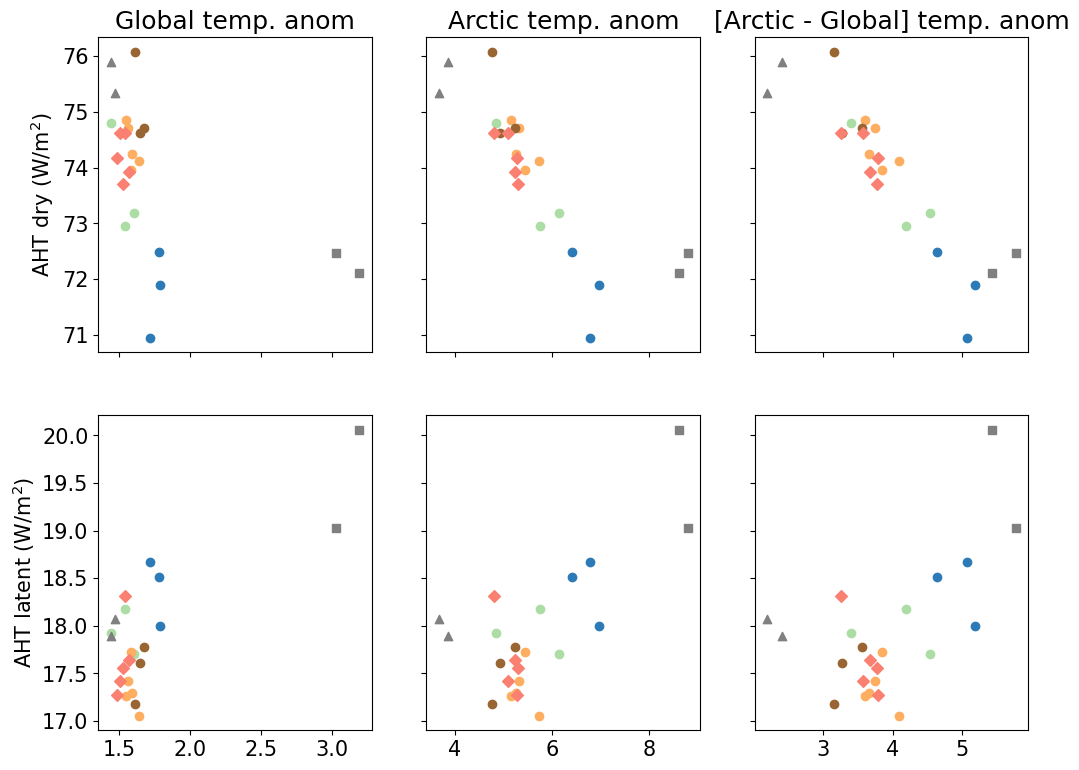

In [35]:
# plot of Qdry and Qmoist against global mean temperature: 

fig, axs = plt.subplots(2, 3, figsize = (12, 9), sharey='row', sharex='col')

for run in ds_dict_sai:
    print(run)
    # get global mean temp: 
    inj = SAI_runs[run]
    global_mean_temp_anom = regional_means_MH_runs[run]['Global'].mean().item() - gmst_pi
    arctic_mean_temp_anom = regional_means_MH_runs[run]['Arctic'].mean().item() - gmst_pi_arctic
    annual_mean_Qdry = ds_dict_sai[run]['Qdry'].mean().item()
    annual_mean_Qmoist = ds_dict_sai[run]['Qmoist'].mean().item()


    axs[0, 0].scatter(global_mean_temp_anom, annual_mean_Qdry, marker='o', c=colours[inj])
    axs[0, 0].set_title('Global temp. anom')
    axs[0, 0].set_ylabel('AHT dry (W/m$^2$)')

    axs[1, 0].scatter(global_mean_temp_anom, annual_mean_Qmoist, marker='o', c=colours[inj])
    #axs[1, 0].set_title()
    axs[1, 0].set_ylabel('AHT latent (W/m$^2$)')

    axs[0, 1].scatter(arctic_mean_temp_anom, annual_mean_Qdry, marker='o', c=colours[inj])
    axs[0, 1].set_title('Arctic temp. anom')
    axs[1, 1].scatter(arctic_mean_temp_anom, annual_mean_Qmoist, marker='o', c=colours[inj])

    axs[0, 2].scatter(arctic_mean_temp_anom - global_mean_temp_anom, annual_mean_Qdry, marker='o', c=colours[inj])
    axs[0, 2].set_title('[Arctic - Global] temp. anom')
    axs[1, 2].scatter(arctic_mean_temp_anom - global_mean_temp_anom, annual_mean_Qmoist, marker='o', c=colours[inj])

# also plot for SSP245: 
for i in range(2): # two ensemble members
    global_mean_temp_anom = regional_means_ssp245['Global'].isel(Ensemble_member=i).mean().tas.item() - gmst_pi
    arctic_mean_temp_anom = regional_means_ssp245['Arctic'].isel(Ensemble_member=i).mean().tas.item() - gmst_pi_arctic
    annual_mean_Qdry = Q_ssp245['Qdry'].isel(Ensemble_member=i).mean().item()
    annual_mean_Qmoist = Q_ssp245['Qmoist'].isel(Ensemble_member=i).mean().item()
    axs[0, 0].scatter(global_mean_temp_anom, annual_mean_Qdry, marker='s', c=colours['ssp245'], label='SSP2-4.5')
    axs[1, 0].scatter(global_mean_temp_anom, annual_mean_Qmoist, marker='s', c=colours['ssp245'])
    axs[0, 1].scatter(arctic_mean_temp_anom, annual_mean_Qdry, marker='s', c=colours['ssp245'])
    axs[1, 1].scatter(arctic_mean_temp_anom, annual_mean_Qmoist, marker='s', c=colours['ssp245'])
    axs[0, 2].scatter(arctic_mean_temp_anom - global_mean_temp_anom, annual_mean_Qdry, marker='s', c=colours['ssp245'])
    axs[1, 2].scatter(arctic_mean_temp_anom - global_mean_temp_anom, annual_mean_Qmoist, marker='s', c=colours['ssp245'])

# also plot for SSP245 baseline:
for i in range(2): # two ensemble members
    global_mean_temp_anom = regional_means_ssp245_baseline['Global'].isel(Ensemble_member=i).mean().tas.item() - gmst_pi
    arctic_mean_temp_anom = regional_means_ssp245_baseline['Arctic'].isel(Ensemble_member=i).mean().tas.item() - gmst_pi_arctic
    annual_mean_Qdry = Q_ssp245_baseline['Qdry'].isel(Ensemble_member=i).mean().item()
    annual_mean_Qmoist = Q_ssp245_baseline['Qmoist'].isel(Ensemble_member=i).mean().item()
    axs[0, 0].scatter(global_mean_temp_anom, annual_mean_Qdry, marker='^', c=colours['ssp245'], label='SSP2-4.5 baseline')
    axs[1, 0].scatter(global_mean_temp_anom, annual_mean_Qmoist, marker='^', c=colours['ssp245'])
    axs[0, 1].scatter(arctic_mean_temp_anom, annual_mean_Qdry, marker='^', c=colours['ssp245'])
    axs[1, 1].scatter(arctic_mean_temp_anom, annual_mean_Qmoist, marker='^', c=colours['ssp245'])
    axs[0, 2].scatter(arctic_mean_temp_anom - global_mean_temp_anom, annual_mean_Qdry, marker='^', c=colours['ssp245'])
    axs[1, 2].scatter(arctic_mean_temp_anom - global_mean_temp_anom, annual_mean_Qmoist, marker='^', c=colours['ssp245'])

# also plot for ARISE:
for i in range(5):
    global_mean_temp_anom = regional_means_ARISE['Global'].isel(Ensemble_member=i).mean().tas.item() - gmst_pi
    arctic_mean_temp_anom = regional_means_ARISE['Arctic'].isel(Ensemble_member=i).mean().tas.item() - gmst_pi_arctic
    annual_mean_Qdry = Q_arise['Qdry'].isel(Ensemble_member=i).mean().item()
    annual_mean_Qmoist = Q_arise['Qmoist'].isel(Ensemble_member=i).mean().item()
    axs[0, 0].scatter(global_mean_temp_anom, annual_mean_Qdry, marker='D', c=colours['ARISE'], label='ARISE')
    axs[1, 0].scatter(global_mean_temp_anom, annual_mean_Qmoist, marker='D', c=colours['ARISE'])
    axs[0, 1].scatter(arctic_mean_temp_anom, annual_mean_Qdry, marker='D', c=colours['ARISE'])
    axs[1, 1].scatter(arctic_mean_temp_anom, annual_mean_Qmoist, marker='D', c=colours['ARISE'])
    axs[0, 2].scatter(arctic_mean_temp_anom - global_mean_temp_anom, annual_mean_Qdry, marker='D', c=colours['ARISE'])
    axs[1, 2].scatter(arctic_mean_temp_anom - global_mean_temp_anom, annual_mean_Qmoist, marker='D', c=colours['ARISE'])


    

de029
de034
cy805
cu743
cy806
cy807
cr991
cs992
cs993
cs994
cs995
ct762
cy808
cy809


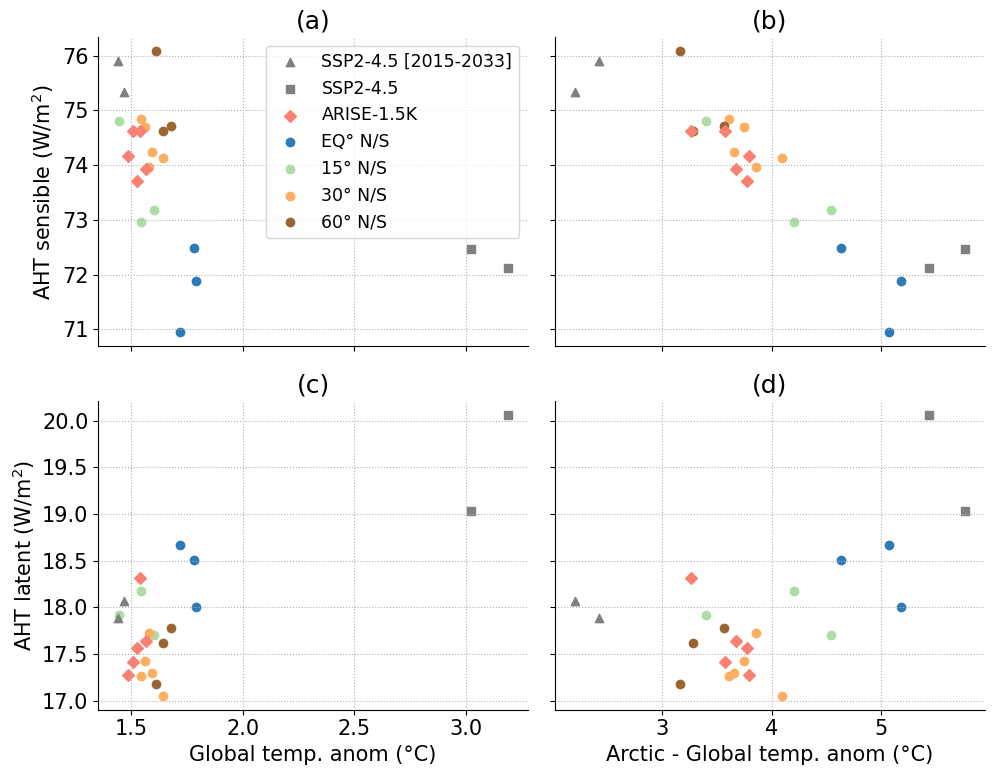

In [36]:
## repeat with just the main two cols: 

# plot of Qdry and Qmoist against global mean temperature: 

fig, axs = plt.subplots(2, 2, figsize = (10, 8), sharey='row', sharex='col')

for run in ds_dict_sai:
    print(run)
    # get global mean temp: 
    inj = SAI_runs[run]
    global_mean_temp_anom = regional_means_MH_runs[run]['Global'].mean().item() - gmst_pi
    arctic_mean_temp_anom = regional_means_MH_runs[run]['Arctic'].mean().item() - gmst_pi_arctic
    annual_mean_Qdry = ds_dict_sai[run]['Qdry'].mean().item()
    annual_mean_Qmoist = ds_dict_sai[run]['Qmoist'].mean().item()


    axs[0, 0].scatter(global_mean_temp_anom, annual_mean_Qdry, marker='o', c=colours[inj])
    axs[0, 0].set_title('Global temp. anom')
    axs[0, 0].set_ylabel('AHT sensible (W/m$^2$)')

    axs[1, 0].scatter(global_mean_temp_anom, annual_mean_Qmoist, marker='o', c=colours[inj])
    #axs[1, 0].set_title()
    axs[1, 0].set_ylabel('AHT latent (W/m$^2$)')

    axs[0, 1].scatter(arctic_mean_temp_anom - global_mean_temp_anom, annual_mean_Qdry, marker='o', c=colours[inj])
    axs[0, 1].set_title('[Arctic - Global] temp. anom')
    axs[1, 1].scatter(arctic_mean_temp_anom - global_mean_temp_anom, annual_mean_Qmoist, marker='o', c=colours[inj])


# also plot for SSP245 baseline:
for i in range(2): # two ensemble members
    global_mean_temp_anom = regional_means_ssp245_baseline['Global'].isel(Ensemble_member=i).mean().tas.item() - gmst_pi
    arctic_mean_temp_anom = regional_means_ssp245_baseline['Arctic'].isel(Ensemble_member=i).mean().tas.item() - gmst_pi_arctic
    annual_mean_Qdry = Q_ssp245_baseline['Qdry'].isel(Ensemble_member=i).mean().item()
    annual_mean_Qmoist = Q_ssp245_baseline['Qmoist'].isel(Ensemble_member=i).mean().item()
    axs[0, 0].scatter(global_mean_temp_anom, annual_mean_Qdry, marker='^', c=colours['ssp245'])
    if i ==0:
        axs[0, 0].scatter([], [], marker='^', c=colours['ssp245'], label='SSP2-4.5 [2015-2033]')
    axs[1, 0].scatter(global_mean_temp_anom, annual_mean_Qmoist, marker='^', c=colours['ssp245'])
    axs[0, 1].scatter(arctic_mean_temp_anom - global_mean_temp_anom, annual_mean_Qdry, marker='^', c=colours['ssp245'])
    axs[1, 1].scatter(arctic_mean_temp_anom - global_mean_temp_anom, annual_mean_Qmoist, marker='^', c=colours['ssp245'])

# also plot for SSP245: 
for i in range(2): # two ensemble members
    global_mean_temp_anom = regional_means_ssp245['Global'].isel(Ensemble_member=i).mean().tas.item() - gmst_pi
    arctic_mean_temp_anom = regional_means_ssp245['Arctic'].isel(Ensemble_member=i).mean().tas.item() - gmst_pi_arctic
    annual_mean_Qdry = Q_ssp245['Qdry'].isel(Ensemble_member=i).mean().item()
    annual_mean_Qmoist = Q_ssp245['Qmoist'].isel(Ensemble_member=i).mean().item()
    axs[0, 0].scatter(global_mean_temp_anom, annual_mean_Qdry, marker='s', c=colours['ssp245'])
    if i ==0:
        axs[0, 0].scatter([], [], marker='s', c=colours['ssp245'], label='SSP2-4.5')
    axs[1, 0].scatter(global_mean_temp_anom, annual_mean_Qmoist, marker='s', c=colours['ssp245'])
    axs[0, 1].scatter(arctic_mean_temp_anom - global_mean_temp_anom, annual_mean_Qdry, marker='s', c=colours['ssp245'])
    axs[1, 1].scatter(arctic_mean_temp_anom - global_mean_temp_anom, annual_mean_Qmoist, marker='s', c=colours['ssp245'])


# also plot for ARISE:
for i in range(5):
    global_mean_temp_anom = regional_means_ARISE['Global'].isel(Ensemble_member=i).mean().tas.item() - gmst_pi
    arctic_mean_temp_anom = regional_means_ARISE['Arctic'].isel(Ensemble_member=i).mean().tas.item() - gmst_pi_arctic
    annual_mean_Qdry = Q_arise['Qdry'].isel(Ensemble_member=i).mean().item()
    annual_mean_Qmoist = Q_arise['Qmoist'].isel(Ensemble_member=i).mean().item()
    axs[0, 0].scatter(global_mean_temp_anom, annual_mean_Qdry, marker='D', c=colours['ARISE'])
    if i ==0:
        axs[0, 0].scatter([], [], marker='D', c=colours['ARISE'], label='ARISE-1.5K')
    axs[1, 0].scatter(global_mean_temp_anom, annual_mean_Qmoist, marker='D', c=colours['ARISE'])
    axs[0, 1].scatter(arctic_mean_temp_anom - global_mean_temp_anom, annual_mean_Qdry, marker='D', c=colours['ARISE'])
    axs[1, 1].scatter(arctic_mean_temp_anom - global_mean_temp_anom, annual_mean_Qmoist, marker='D', c=colours['ARISE'])

for inj in ['EQ', '15', '30', '60']:
    axs[0, 0].scatter([], [], marker='o', c=colours[inj], label='{}° N/S'.format(inj))

axs[0, 0].legend(fontsize='small', ncols=1, loc='upper right')
axs[1,0].set_xlabel('Global temp. anom (°C)')
axs[1,1].set_xlabel('Arctic - Global temp. anom (°C)')

for ax in axs.flatten():
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.grid(ls='dotted')
    ax.set_title(['(a)', '(b)', '(c)', '(d)'][list(axs.flatten()).index(ax)])

plt.tight_layout()
plt.savefig('figures/AHT_latent_and_sensible_vs_temp_anoms.jpg', dpi=300, bbox_inches='tight')

de029
de034
cy805
cu743
cy806
cy807
cr991
cs992
cs993
cs994
cs995
ct762
cy808
cy809


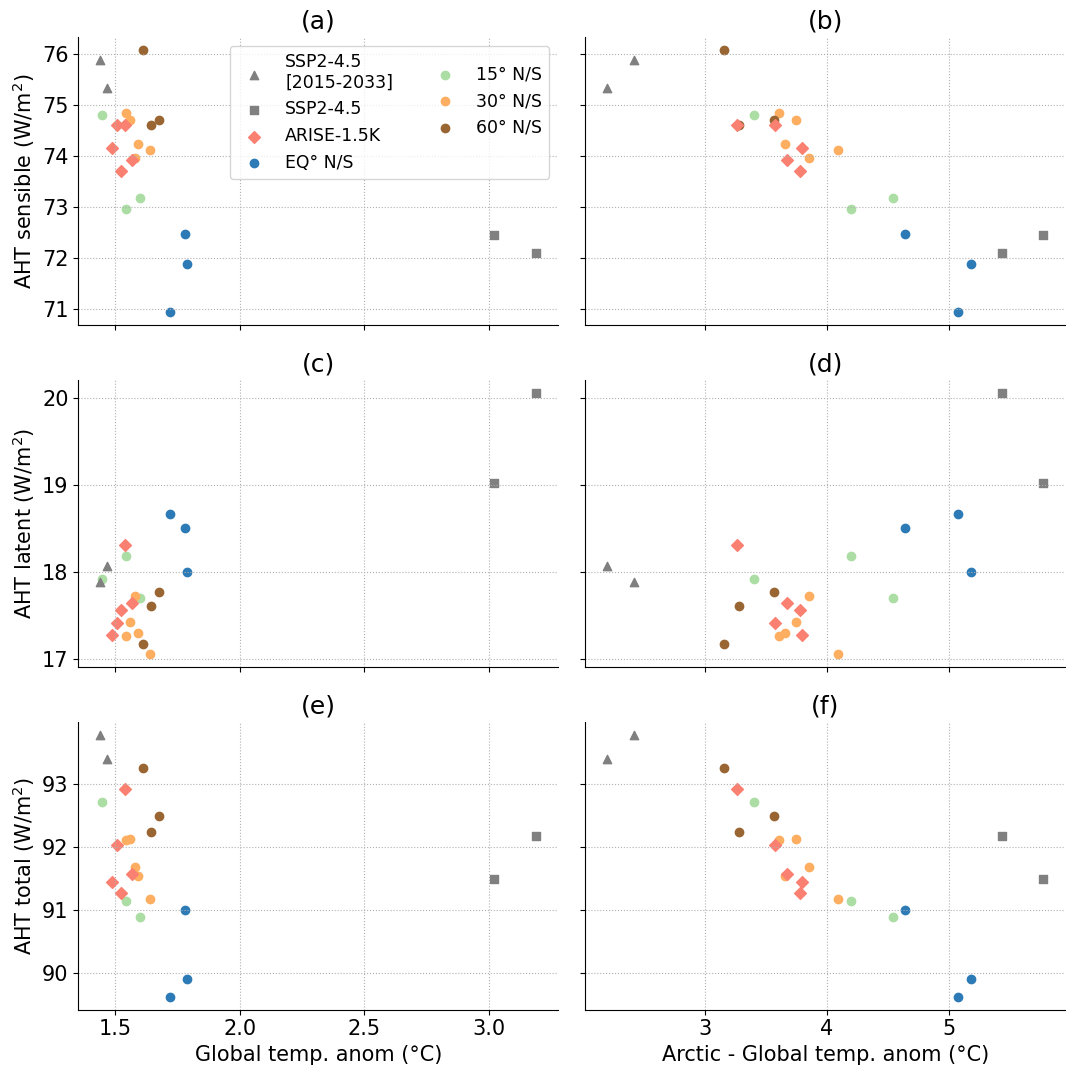

In [37]:
## repeat with just the main two cols: 

# plot of Qdry and Qmoist against global mean temperature: 

fig, axs = plt.subplots(3, 2, figsize = (11, 11), sharey='row', sharex='col')

for run in ds_dict_sai:
    print(run)
    # get global mean temp: 
    inj = SAI_runs[run]
    global_mean_temp_anom = regional_means_MH_runs[run]['Global'].mean().item() - gmst_pi
    arctic_mean_temp_anom = regional_means_MH_runs[run]['Arctic'].mean().item() - gmst_pi_arctic
    annual_mean_Qdry = ds_dict_sai[run]['Qdry'].mean().item()
    annual_mean_Qmoist = ds_dict_sai[run]['Qmoist'].mean().item()


    axs[0, 0].scatter(global_mean_temp_anom, annual_mean_Qdry, marker='o', c=colours[inj])
    axs[0, 0].set_title('Global temp. anom')
    axs[0, 0].set_ylabel('AHT sensible (W/m$^2$)')

    axs[1, 0].scatter(global_mean_temp_anom, annual_mean_Qmoist, marker='o', c=colours[inj])
    #axs[1, 0].set_title()
    axs[1, 0].set_ylabel('AHT latent (W/m$^2$)')

    axs[0, 1].scatter(arctic_mean_temp_anom - global_mean_temp_anom, annual_mean_Qdry, marker='o', c=colours[inj])
    axs[0, 1].set_title('[Arctic - Global] temp. anom')

    axs[1, 1].scatter(arctic_mean_temp_anom - global_mean_temp_anom, annual_mean_Qmoist, marker='o', c=colours[inj])

    axs[2, 0].scatter(global_mean_temp_anom, annual_mean_Qmoist+annual_mean_Qdry, marker='o', c=colours[inj])
    axs[2, 0].set_ylabel('AHT total (W/m$^2$)')

    axs[2, 1].scatter(arctic_mean_temp_anom - global_mean_temp_anom, annual_mean_Qmoist+annual_mean_Qdry, marker='o', c=colours[inj])

# also plot for SSP245 baseline:
for i in range(2): # two ensemble members
    global_mean_temp_anom = regional_means_ssp245_baseline['Global'].isel(Ensemble_member=i).mean().tas.item() - gmst_pi
    arctic_mean_temp_anom = regional_means_ssp245_baseline['Arctic'].isel(Ensemble_member=i).mean().tas.item() - gmst_pi_arctic
    annual_mean_Qdry = Q_ssp245_baseline['Qdry'].isel(Ensemble_member=i).mean().item()
    annual_mean_Qmoist = Q_ssp245_baseline['Qmoist'].isel(Ensemble_member=i).mean().item()
    axs[0, 0].scatter(global_mean_temp_anom, annual_mean_Qdry, marker='^', c=colours['ssp245'])
    if i ==0:
        axs[0, 0].scatter([], [], marker='^', c=colours['ssp245'], label='SSP2-4.5\n[2015-2033]')
    axs[1, 0].scatter(global_mean_temp_anom, annual_mean_Qmoist, marker='^', c=colours['ssp245'])
    axs[0, 1].scatter(arctic_mean_temp_anom - global_mean_temp_anom, annual_mean_Qdry, marker='^', c=colours['ssp245'])
    axs[1, 1].scatter(arctic_mean_temp_anom - global_mean_temp_anom, annual_mean_Qmoist, marker='^', c=colours['ssp245'])
    axs[2, 0].scatter(global_mean_temp_anom, annual_mean_Qdry+annual_mean_Qmoist, marker='^', c=colours['ssp245'])
    axs[2, 1].scatter(arctic_mean_temp_anom - global_mean_temp_anom, annual_mean_Qdry+annual_mean_Qmoist, marker='^', c=colours['ssp245'])

# also plot for SSP245: 
for i in range(2): # two ensemble members
    global_mean_temp_anom = regional_means_ssp245['Global'].isel(Ensemble_member=i).mean().tas.item() - gmst_pi
    arctic_mean_temp_anom = regional_means_ssp245['Arctic'].isel(Ensemble_member=i).mean().tas.item() - gmst_pi_arctic
    annual_mean_Qdry = Q_ssp245['Qdry'].isel(Ensemble_member=i).mean().item()
    annual_mean_Qmoist = Q_ssp245['Qmoist'].isel(Ensemble_member=i).mean().item()
    axs[0, 0].scatter(global_mean_temp_anom, annual_mean_Qdry, marker='s', c=colours['ssp245'])
    if i ==0:
        axs[0, 0].scatter([], [], marker='s', c=colours['ssp245'], label='SSP2-4.5')
    axs[1, 0].scatter(global_mean_temp_anom, annual_mean_Qmoist, marker='s', c=colours['ssp245'])
    axs[0, 1].scatter(arctic_mean_temp_anom - global_mean_temp_anom, annual_mean_Qdry, marker='s', c=colours['ssp245'])
    axs[1, 1].scatter(arctic_mean_temp_anom - global_mean_temp_anom, annual_mean_Qmoist, marker='s', c=colours['ssp245'])
    axs[2, 0].scatter(global_mean_temp_anom, annual_mean_Qdry+annual_mean_Qmoist, marker='s', c=colours['ssp245'])
    axs[2, 1].scatter(arctic_mean_temp_anom - global_mean_temp_anom, annual_mean_Qdry+annual_mean_Qmoist, marker='s', c=colours['ssp245'])


# also plot for ARISE:
for i in range(5):
    global_mean_temp_anom = regional_means_ARISE['Global'].isel(Ensemble_member=i).mean().tas.item() - gmst_pi
    arctic_mean_temp_anom = regional_means_ARISE['Arctic'].isel(Ensemble_member=i).mean().tas.item() - gmst_pi_arctic
    annual_mean_Qdry = Q_arise['Qdry'].isel(Ensemble_member=i).mean().item()
    annual_mean_Qmoist = Q_arise['Qmoist'].isel(Ensemble_member=i).mean().item()
    axs[0, 0].scatter(global_mean_temp_anom, annual_mean_Qdry, marker='D', c=colours['ARISE'])
    if i ==0:
        axs[0, 0].scatter([], [], marker='D', c=colours['ARISE'], label='ARISE-1.5K')
    axs[1, 0].scatter(global_mean_temp_anom, annual_mean_Qmoist, marker='D', c=colours['ARISE'])
    axs[0, 1].scatter(arctic_mean_temp_anom - global_mean_temp_anom, annual_mean_Qdry, marker='D', c=colours['ARISE'])
    axs[1, 1].scatter(arctic_mean_temp_anom - global_mean_temp_anom, annual_mean_Qmoist, marker='D', c=colours['ARISE'])
    axs[2, 0].scatter(global_mean_temp_anom, annual_mean_Qdry+annual_mean_Qmoist, marker='D', c=colours['ARISE'])
    axs[2, 1].scatter(arctic_mean_temp_anom - global_mean_temp_anom, annual_mean_Qdry+annual_mean_Qmoist, marker='D', c=colours['ARISE'])

for inj in ['EQ', '15', '30', '60']:
    axs[0, 0].scatter([], [], marker='o', c=colours[inj], label='{}° N/S'.format(inj))

axs[0, 0].legend(fontsize='small', ncols=2, loc='upper right')
axs[2,0].set_xlabel('Global temp. anom (°C)')
axs[2,1].set_xlabel('Arctic - Global temp. anom (°C)')

for ax in axs.flatten():
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.grid(ls='dotted')
    ax.set_title(['(a)', '(b)', '(c)', '(d)', '(e)', '(f)'][list(axs.flatten()).index(ax)])

plt.tight_layout()
plt.savefig('figures/AHT_latent_sensible_total_vs_temp_anoms.jpg', dpi=300, bbox_inches='tight')

de029
de034
cy805
cu743
cy806
cy807
cr991
cs992
cs993
cs994
cs995
ct762
cy808
cy809


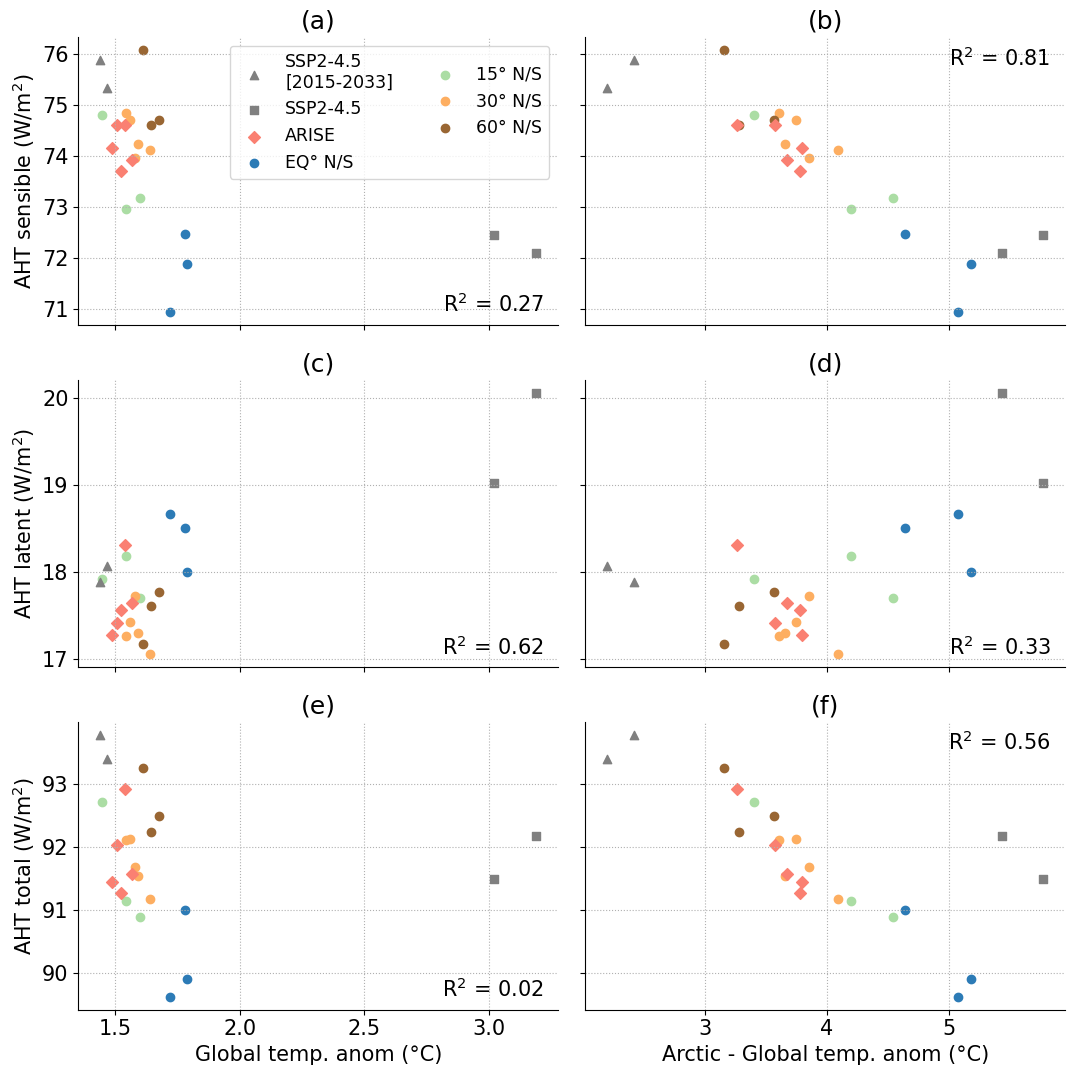

In [38]:
## repeat with just the main two cols: 

# plot of Qdry and Qmoist against global mean temperature: 

import numpy as np

fig, axs = plt.subplots(3, 2, figsize = (11, 11), sharey='row', sharex='col')

# (row, col) -> ([x values], [y values]) for R2 calculation
panel_data = {(i, j): ([], []) for i in range(3) for j in range(2)}

def record_point(g_anom, ag_anom, qdry, qmoist):
    """Store point in the panel-wise data for R2 calculation."""
    for (i, j), (x, y) in panel_data.items():
        x.append(g_anom if j == 0 else ag_anom)
        y.append([qdry, qmoist, qdry + qmoist][i])

for run in ds_dict_sai:
    print(run)
    # get global mean temp: 
    inj = SAI_runs[run]
    global_mean_temp_anom = regional_means_MH_runs[run]['Global'].mean().item() - gmst_pi
    arctic_mean_temp_anom = regional_means_MH_runs[run]['Arctic'].mean().item() - gmst_pi_arctic
    annual_mean_Qdry = ds_dict_sai[run]['Qdry'].mean().item()
    annual_mean_Qmoist = ds_dict_sai[run]['Qmoist'].mean().item()

    record_point(global_mean_temp_anom,
                 arctic_mean_temp_anom - global_mean_temp_anom,
                 annual_mean_Qdry, annual_mean_Qmoist)

    axs[0, 0].scatter(global_mean_temp_anom, annual_mean_Qdry, marker='o', c=colours[inj])
    axs[0, 0].set_title('Global temp. anom')
    axs[0, 0].set_ylabel('AHT sensible (W/m$^2$)')

    axs[1, 0].scatter(global_mean_temp_anom, annual_mean_Qmoist, marker='o', c=colours[inj])
    #axs[1, 0].set_title()
    axs[1, 0].set_ylabel('AHT latent (W/m$^2$)')

    axs[0, 1].scatter(arctic_mean_temp_anom - global_mean_temp_anom, annual_mean_Qdry, marker='o', c=colours[inj])
    axs[0, 1].set_title('[Arctic - Global] temp. anom')

    axs[1, 1].scatter(arctic_mean_temp_anom - global_mean_temp_anom, annual_mean_Qmoist, marker='o', c=colours[inj])

    axs[2, 0].scatter(global_mean_temp_anom, annual_mean_Qmoist+annual_mean_Qdry, marker='o', c=colours[inj])
    axs[2, 0].set_ylabel('AHT total (W/m$^2$)')

    axs[2, 1].scatter(arctic_mean_temp_anom - global_mean_temp_anom, annual_mean_Qmoist+annual_mean_Qdry, marker='o', c=colours[inj])

# also plot for SSP245 baseline:
for i in range(2): # two ensemble members
    global_mean_temp_anom = regional_means_ssp245_baseline['Global'].isel(Ensemble_member=i).mean().tas.item() - gmst_pi
    arctic_mean_temp_anom = regional_means_ssp245_baseline['Arctic'].isel(Ensemble_member=i).mean().tas.item() - gmst_pi_arctic
    annual_mean_Qdry = Q_ssp245_baseline['Qdry'].isel(Ensemble_member=i).mean().item()
    annual_mean_Qmoist = Q_ssp245_baseline['Qmoist'].isel(Ensemble_member=i).mean().item()

    record_point(global_mean_temp_anom,
                 arctic_mean_temp_anom - global_mean_temp_anom,
                 annual_mean_Qdry, annual_mean_Qmoist)

    axs[0, 0].scatter(global_mean_temp_anom, annual_mean_Qdry, marker='^', c=colours['ssp245'])
    if i ==0:
        axs[0, 0].scatter([], [], marker='^', c=colours['ssp245'], label='SSP2-4.5\n[2015-2033]')
    axs[1, 0].scatter(global_mean_temp_anom, annual_mean_Qmoist, marker='^', c=colours['ssp245'])
    axs[0, 1].scatter(arctic_mean_temp_anom - global_mean_temp_anom, annual_mean_Qdry, marker='^', c=colours['ssp245'])
    axs[1, 1].scatter(arctic_mean_temp_anom - global_mean_temp_anom, annual_mean_Qmoist, marker='^', c=colours['ssp245'])
    axs[2, 0].scatter(global_mean_temp_anom, annual_mean_Qdry+annual_mean_Qmoist, marker='^', c=colours['ssp245'])
    axs[2, 1].scatter(arctic_mean_temp_anom - global_mean_temp_anom, annual_mean_Qdry+annual_mean_Qmoist, marker='^', c=colours['ssp245'])

# also plot for SSP245: 
for i in range(2): # two ensemble members
    global_mean_temp_anom = regional_means_ssp245['Global'].isel(Ensemble_member=i).mean().tas.item() - gmst_pi
    arctic_mean_temp_anom = regional_means_ssp245['Arctic'].isel(Ensemble_member=i).mean().tas.item() - gmst_pi_arctic
    annual_mean_Qdry = Q_ssp245['Qdry'].isel(Ensemble_member=i).mean().item()
    annual_mean_Qmoist = Q_ssp245['Qmoist'].isel(Ensemble_member=i).mean().item()

    record_point(global_mean_temp_anom,
                 arctic_mean_temp_anom - global_mean_temp_anom,
                 annual_mean_Qdry, annual_mean_Qmoist)

    axs[0, 0].scatter(global_mean_temp_anom, annual_mean_Qdry, marker='s', c=colours['ssp245'])
    if i ==0:
        axs[0, 0].scatter([], [], marker='s', c=colours['ssp245'], label='SSP2-4.5')
    axs[1, 0].scatter(global_mean_temp_anom, annual_mean_Qmoist, marker='s', c=colours['ssp245'])
    axs[0, 1].scatter(arctic_mean_temp_anom - global_mean_temp_anom, annual_mean_Qdry, marker='s', c=colours['ssp245'])
    axs[1, 1].scatter(arctic_mean_temp_anom - global_mean_temp_anom, annual_mean_Qmoist, marker='s', c=colours['ssp245'])
    axs[2, 0].scatter(global_mean_temp_anom, annual_mean_Qdry+annual_mean_Qmoist, marker='s', c=colours['ssp245'])
    axs[2, 1].scatter(arctic_mean_temp_anom - global_mean_temp_anom, annual_mean_Qdry+annual_mean_Qmoist, marker='s', c=colours['ssp245'])


# also plot for ARISE:
for i in range(5):
    global_mean_temp_anom = regional_means_ARISE['Global'].isel(Ensemble_member=i).mean().tas.item() - gmst_pi
    arctic_mean_temp_anom = regional_means_ARISE['Arctic'].isel(Ensemble_member=i).mean().tas.item() - gmst_pi_arctic
    annual_mean_Qdry = Q_arise['Qdry'].isel(Ensemble_member=i).mean().item()
    annual_mean_Qmoist = Q_arise['Qmoist'].isel(Ensemble_member=i).mean().item()

    record_point(global_mean_temp_anom,
                 arctic_mean_temp_anom - global_mean_temp_anom,
                 annual_mean_Qdry, annual_mean_Qmoist)

    axs[0, 0].scatter(global_mean_temp_anom, annual_mean_Qdry, marker='D', c=colours['ARISE'])
    if i ==0:
        axs[0, 0].scatter([], [], marker='D', c=colours['ARISE'], label='ARISE')
    axs[1, 0].scatter(global_mean_temp_anom, annual_mean_Qmoist, marker='D', c=colours['ARISE'])
    axs[0, 1].scatter(arctic_mean_temp_anom - global_mean_temp_anom, annual_mean_Qdry, marker='D', c=colours['ARISE'])
    axs[1, 1].scatter(arctic_mean_temp_anom - global_mean_temp_anom, annual_mean_Qmoist, marker='D', c=colours['ARISE'])
    axs[2, 0].scatter(global_mean_temp_anom, annual_mean_Qdry+annual_mean_Qmoist, marker='D', c=colours['ARISE'])
    axs[2, 1].scatter(arctic_mean_temp_anom - global_mean_temp_anom, annual_mean_Qdry+annual_mean_Qmoist, marker='D', c=colours['ARISE'])

for inj in ['EQ', '15', '30', '60']:
    axs[0, 0].scatter([], [], marker='o', c=colours[inj], label='{}° N/S'.format(inj))

axs[0, 0].legend(fontsize='small', ncols=2, loc='upper right')
axs[2,0].set_xlabel('Global temp. anom (°C)')
axs[2,1].set_xlabel('Arctic - Global temp. anom (°C)')

for ax in axs.flatten():
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.grid(ls='dotted')
    ax.set_title(['(a)', '(b)', '(c)', '(d)', '(e)', '(f)'][list(axs.flatten()).index(ax)])

# R2 annotations: top right for panels (b) and (f), bottom right elsewhere
top_right_panels = [(0, 1), (2, 1)]  # (b) and (f)
for (i, j), (x, y) in panel_data.items():
    r2 = np.corrcoef(x, y)[0, 1] ** 2
    if (i, j) in top_right_panels:
        ypos, va = 0.97, 'top'
    else:
        ypos, va = 0.03, 'bottom'
    axs[i, j].text(0.97, ypos, f'R$^2$ = {r2:.2f}',
                   transform=axs[i, j].transAxes,
                   ha='right', va=va, fontsize='medium')

plt.tight_layout()
plt.savefig('figures/AHT_latent_sensible_total_vs_temp_anoms.jpg', dpi=300, bbox_inches='tight')

In [39]:
## print the diff between EQ and 60NS AHT total:
EQ_totals = []
totals_60 = []

for run in ds_dict_sai:
    print(run)
    # get global mean temp: 
    inj = SAI_runs[run]
    if inj == 'EQ':
        EQ_totals.append(ds_dict_sai[run]['Qdry'].mean().item() + ds_dict_sai[run]['Qmoist'].mean().item())
    elif inj == '60':
        totals_60.append(ds_dict_sai[run]['Qdry'].mean().item() + ds_dict_sai[run]['Qmoist'].mean().item())

print(np.mean(EQ_totals))
print(np.mean(totals_60))
print(np.mean(totals_60) - np.mean(EQ_totals))


de029
de034
cy805
cu743
cy806
cy807
cr991
cs992
cs993
cs994
cs995
ct762
cy808
cy809
90.16709899902344
92.65825907389323
2.4911600748697964


In [40]:
2.4911/3.615

0.6891009681881051

In [41]:
### FIXED: ds_ssp245 was being overwritten by the gridded all-member read-in; those are now
## named ds_ssp245_gridded / ds_ssp245_baseline_gridded so the Arctic-mean ds_ssp245 survives.

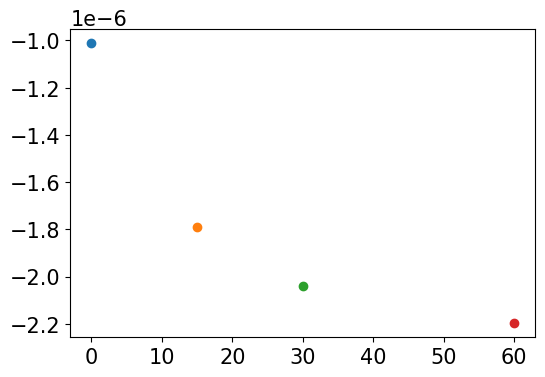

In [42]:

ds_dict = {'EQ':ds_EQ.mean('Ensemble_member') - ds_ssp245,
           '15° NS':ds_15.mean('Ensemble_member') - ds_ssp245,
           '30° NS':ds_30.mean('Ensemble_member') - ds_ssp245,
           '60° NS':ds_60.mean('Ensemble_member') - ds_ssp245,
          }

titles_to_ints = {'EQ':0,
                  '15° NS':15,
                  '30° NS':30,
                  '60° NS':60
                 }
    
fig, ax = plt.subplots(1, 1, figsize = (6, 4), sharey=True)
    
i=0
for title in ds_dict:
    ds = ds_dict[title].mean('month')
    ax.scatter(titles_to_ints[title], ds['pr'])
    

In [43]:
matplotlib.rcParams.update({'font.size': 17})


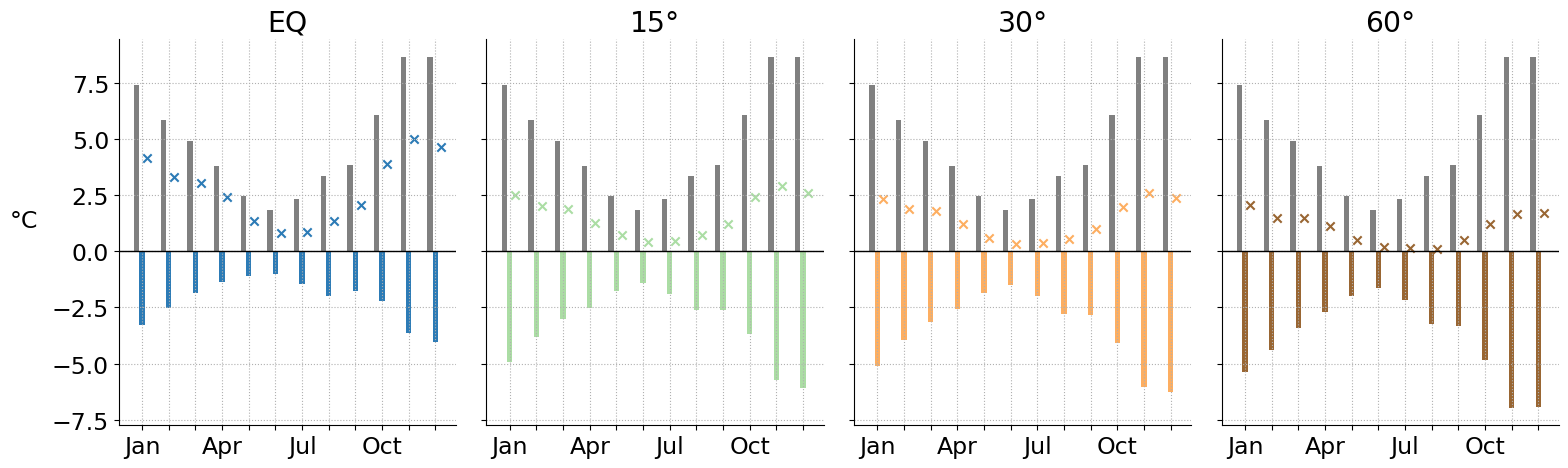

In [44]:
### plot seasonality of cooling
inj='EQ'

colours = {'ssp245':'gray',
           'ssp245_light':'lightgray',
           'EQ':'#2C7BB6',
           '15':'#ABDDA4',
           '30':'#FDAE61',
           '60':'#996633'}

months = np.arange(1, 13)
#colors=['lightblue', 'royalblue']
# Extract raw values

#cooling_values_raw = {k: v.values for k, v in cooling.items()}

# Calculate annual means
#warming_mean = warming_values.mean()
#cooling_means = {k: vals.mean() for k, vals in cooling_values_raw.items()}

# Normalize: divide each month by its series mean
#warming_norm = warming_values / warming_mean
#cooling_norm = {k: (-vals / mean) for k, (vals, mean) in zip(cooling_values_raw.keys(),
#                                                              zip(cooling_values_raw.values(), cooling_means.values()))}

# Set bar width
width = 0.2

# Create plot
fig, axs = plt.subplots(1, 4, figsize=(16, 5), sharey=True)

j=0
for inj_ds in [ds_EQ, ds_15, ds_30, ds_60]:
    ax = axs[j]
    inj = ['EQ', '15', '30', '60'][j]
    warming = ds_ssp245.tas - ds_ssp245_base.tas
    cooling = inj_ds.mean('Ensemble_member').tas - ds_ssp245.tas
    
    # Plot warming bars (shifted left)
    ax.bar(months - width, warming.values, width=width, label='Warming: SSP2-4.5', color='gray')
    ax.bar(months, cooling.values, width=width, label='Cooling: {}'.format(inj), color=colours[inj])
    ax.scatter(months + width, warming.values+cooling.values, label='Residual: {}'.format(inj), color=colours[inj], marker='x')
    
    ax.axhline(0, color='black', linewidth=1)
    ax.set_xticks(months)
    ax.set_xticklabels(['Jan', '', '', 'Apr', '', '',
                        'Jul', '', '', 'Oct', '', ''])
    
    ax.set_title(inj+'°')
    if j==0:
        ax.set_title(inj)
        ax.set_ylabel('°C', rotation=0, labelpad=20)
    #ax.legend()
    ax.grid(ls='dotted')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    j=j+1
plt.tight_layout()
plt.savefig('figures/Cooling_seasonality.jpg', dpi=350)

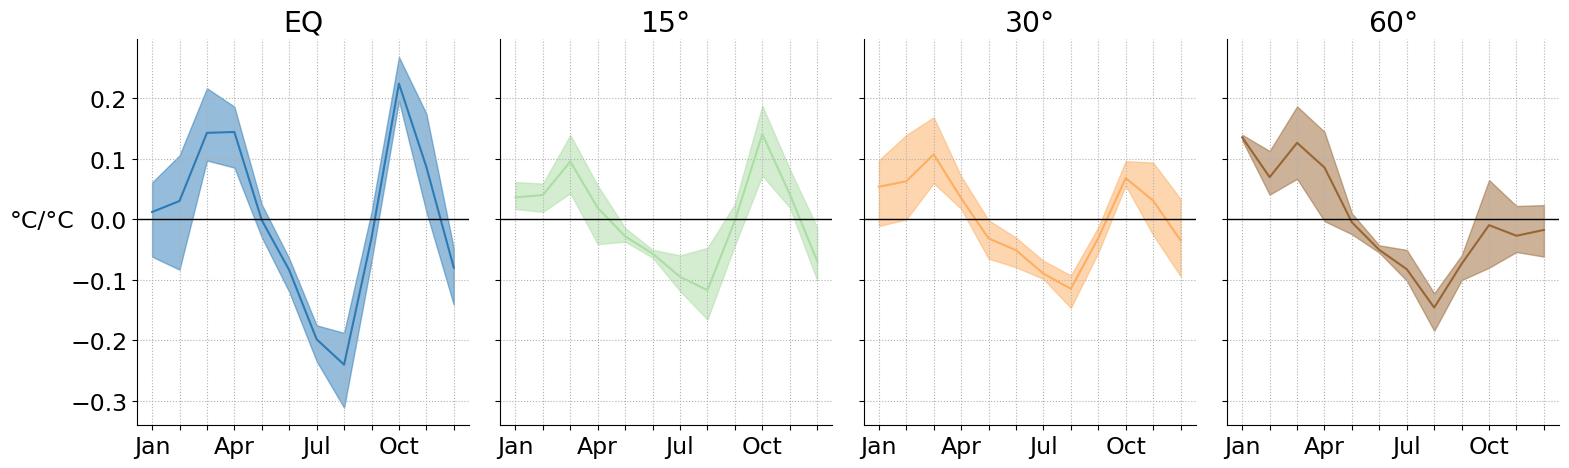

In [46]:
### plot seasonality of cooling
inj='EQ'

colours = {'ssp245':'gray',
           'ssp245_light':'lightgray',
           'EQ':'#2C7BB6',
           '15':'#ABDDA4',
           '30':'#FDAE61',
           '60':'#996633'}

months = np.arange(1, 13)
#colors=['lightblue', 'royalblue']
# Extract raw values

#cooling_values_raw = {k: v.values for k, v in cooling.items()}

# Calculate annual means
#warming_mean = warming_values.mean()
#cooling_means = {k: vals.mean() for k, vals in cooling_values_raw.items()}

# Normalize: divide each month by its series mean
#warming_norm = warming_values / warming_mean
#cooling_norm = {k: (-vals / mean) for k, (vals, mean) in zip(cooling_values_raw.keys(),
#                                                              zip(cooling_values_raw.values(), cooling_means.values()))}

# Set bar width
width = 0.2

# Create plot
fig, axs = plt.subplots(1, 4, figsize=(16, 5), sharey=True)

j=0
for inj_ds in [ds_EQ, ds_15, ds_30, ds_60]:
    ax = axs[j]
    inj = ['EQ', '15', '30', '60'][j]
    warming = ds_ssp245.tas - ds_ssp245_base.tas
    cooling = inj_ds.tas - ds_ssp245.tas

    warming_mean = warming.mean()
    cooling_mean = cooling.mean('month')

    warming_norm = warming/warming_mean
    cooling_norm = -cooling/cooling_mean

    resid = warming_norm+cooling_norm
   
    ax.plot(resid.mean('Ensemble_member').month, resid.mean('Ensemble_member').values, label='Residual: {}'.format(inj), color=colours[inj])
    ax.fill_between(resid.isel(Ensemble_member=0).month.values, 
                    resid.min('Ensemble_member').values, 
                    resid.max('Ensemble_member').values, 
                    color=colours[inj], alpha=0.5)
    
    ax.axhline(0, color='black', linewidth=1)
    ax.set_xticks(months)
    ax.set_xticklabels(['Jan', '', '', 'Apr', '', '',
                        'Jul', '', '', 'Oct', '', ''])
    
    ax.set_title(inj+'°')
    if j==0:
        ax.set_title(inj)
        ax.set_ylabel('°C/°C', rotation=0, labelpad=20)
    #ax.legend()
    ax.grid(ls='dotted')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    j=j+1
plt.tight_layout()
plt.savefig('figures/Cooling_seasonality_normed.jpg', dpi=350)

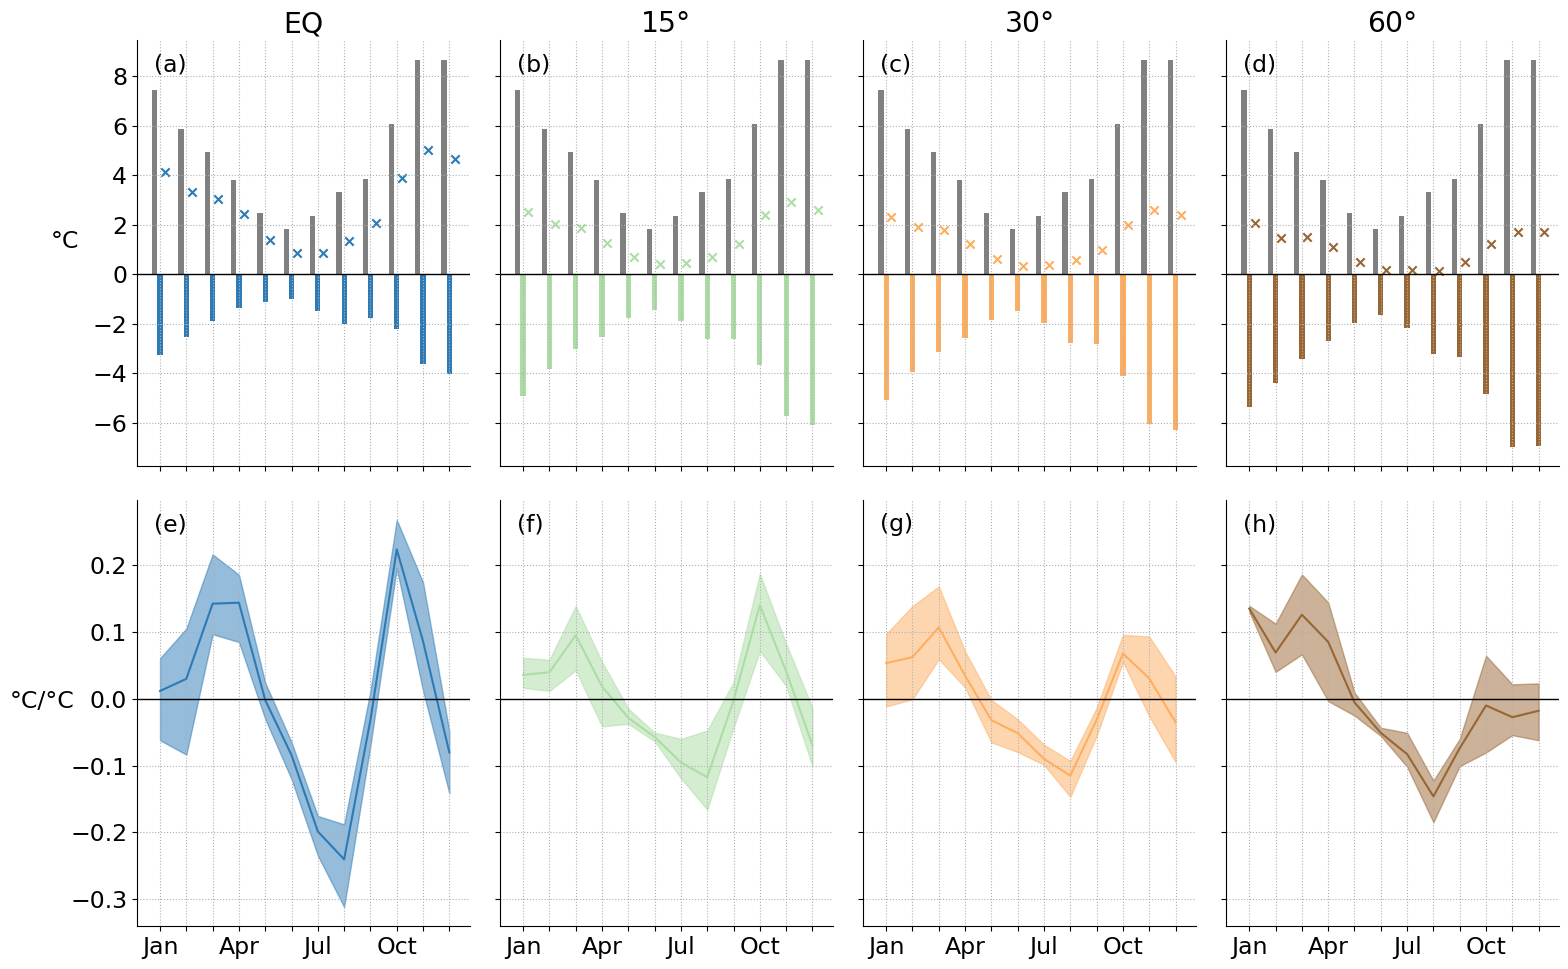

In [47]:
## combine the two figs above into one 8subpanel fig: 
fig, axs = plt.subplots(2, 4, figsize=(16, 10), sharey='row', sharex=True)


j=0
for inj_ds in [ds_EQ, ds_15, ds_30, ds_60]:
    ax = axs[0, j]
    inj = ['EQ', '15', '30', '60'][j]
    warming = ds_ssp245.tas - ds_ssp245_base.tas
    cooling = inj_ds.mean('Ensemble_member').tas - ds_ssp245.tas
    
    # Plot warming bars (shifted left)
    ax.bar(months - width, warming.values, width=width, label='Warming: SSP2-4.5', color='gray')
    ax.bar(months, cooling.values, width=width, label='Cooling: {}'.format(inj), color=colours[inj])
    ax.scatter(months + width, warming.values+cooling.values, label='Residual: {}'.format(inj), color=colours[inj], marker='x')
    
    ax.axhline(0, color='black', linewidth=1)
    ax.set_xticks(months)
    ax.set_xticklabels(['Jan', '', '', 'Apr', '', '',
                        'Jul', '', '', 'Oct', '', ''])
    
    ax.set_title(inj+'°')

    if j==0:
        ax.set_title(inj)
        ax.set_ylabel('°C', rotation=0, labelpad=20)
    #ax.legend()
    ax.grid(ls='dotted')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    j=j+1

j=0
for inj_ds in [ds_EQ, ds_15, ds_30, ds_60]:
    ax = axs[1, j]
    inj = ['EQ', '15', '30', '60'][j]
    warming = ds_ssp245.tas - ds_ssp245_base.tas
    cooling = inj_ds.tas - ds_ssp245.tas

    warming_mean = warming.mean()
    cooling_mean = cooling.mean('month')

    warming_norm = warming/warming_mean
    cooling_norm = -cooling/cooling_mean

    resid = warming_norm+cooling_norm
   
    ax.plot(resid.mean('Ensemble_member').month, resid.mean('Ensemble_member').values, label='Residual: {}'.format(inj), color=colours[inj])
    ax.fill_between(resid.isel(Ensemble_member=0).month.values, 
                    resid.min('Ensemble_member').values, 
                    resid.max('Ensemble_member').values, 
                    color=colours[inj], alpha=0.5)
    
    ax.axhline(0, color='black', linewidth=1)
    ax.set_xticks(months)
    ax.set_xticklabels(['Jan', '', '', 'Apr', '', '',
                        'Jul', '', '', 'Oct', '', ''])
    
    #ax.legend()
    ax.grid(ls='dotted')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    j=j+1
axs[1, 0].set_ylabel('°C/°C', rotation=0, labelpad=20)

# label top left of each plot (a), (b) etc.
for ax in axs.flatten():
    ax.text(0.05, 0.97, '({})'.format(chr(97 + list(axs.flatten()).index(ax))), transform=ax.transAxes, fontsize='medium', va='top', ha='left')

plt.tight_layout()
plt.savefig('figures/Cooling_seasonality_combined.jpg', dpi=350)

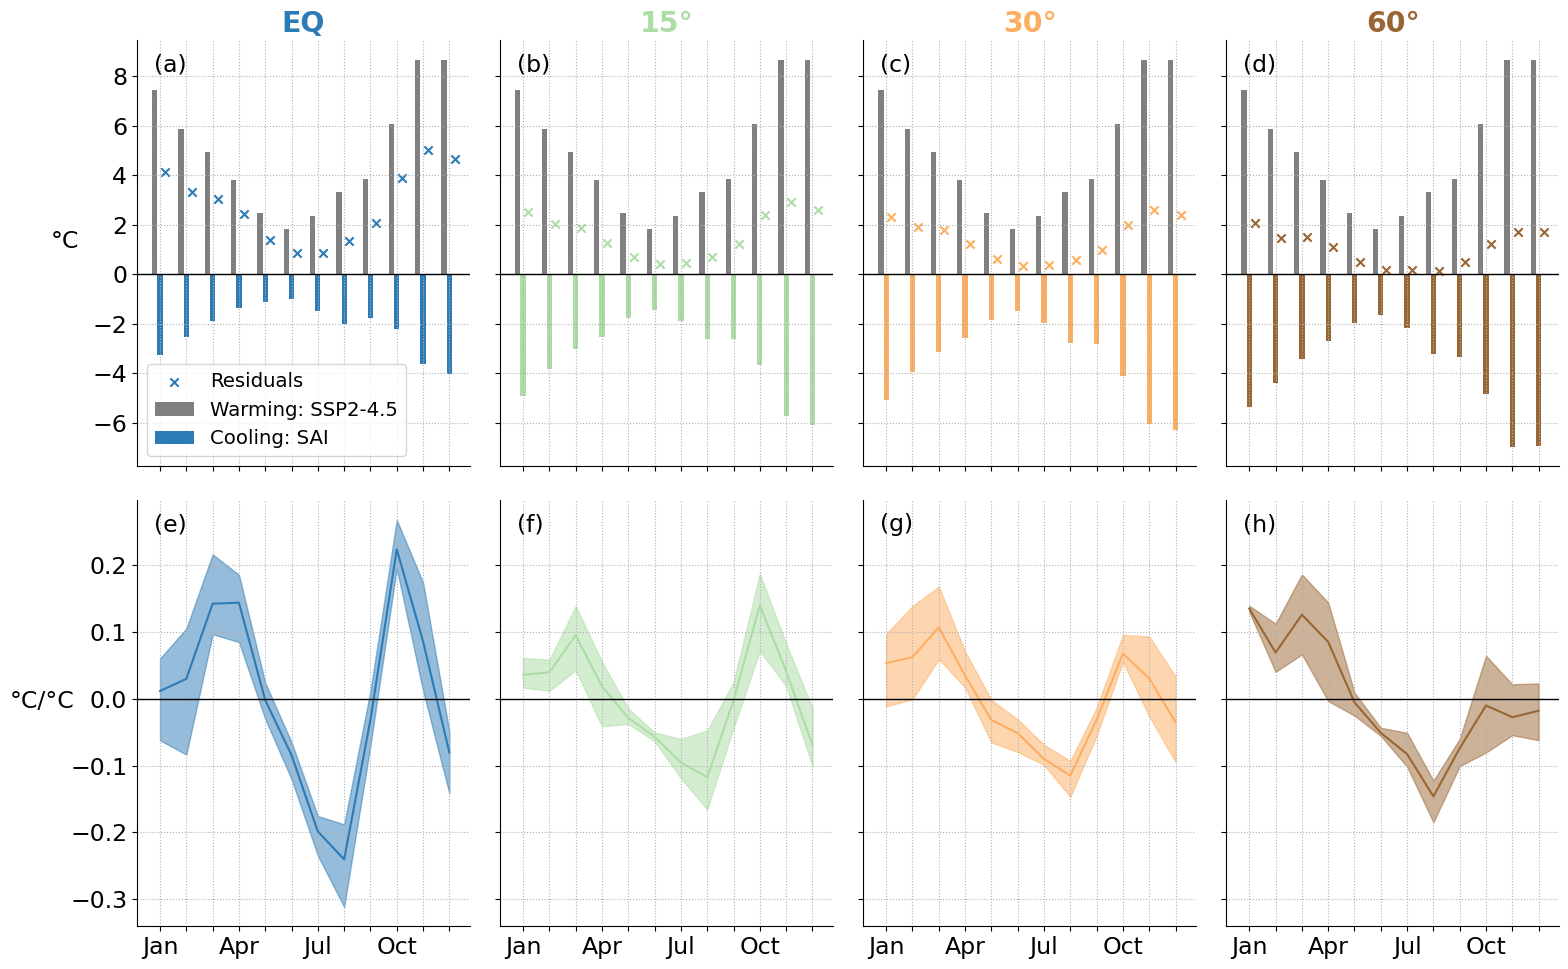

In [48]:
fig, axs = plt.subplots(2, 4, figsize=(16, 10), sharey='row', sharex=True)

inj_datasets = [ds_EQ, ds_15, ds_30, ds_60]
inj_labels = ['EQ', '15', '30', '60']

for j, (inj_ds, inj) in enumerate(zip(inj_datasets, inj_labels)):
    # --- Top row: bar charts ---
    ax = axs[0, j]
    warming = ds_ssp245.tas - ds_ssp245_base.tas
    cooling = inj_ds.mean('Ensemble_member').tas - ds_ssp245.tas

    ax.bar(months - width, warming.values, width=width, label='Warming: SSP2-4.5', color='gray')
    ax.bar(months, cooling.values, width=width, label='Cooling: SAI'.format(inj), color=colours[inj])
    ax.scatter(months + width, warming.values + cooling.values, label='Residuals'.format(inj), color=colours[inj], marker='x')

    ax.set_title(inj if inj == 'EQ' else inj + '°', color=colours[inj], fontweight='bold')
    if j == 0:
        ax.set_ylabel('°C', rotation=0, labelpad=20)
        #ax.scatter([], [], marker='x', color='grey', label='Residuals')
        ax.legend(loc='lower left', fontsize='small')

    # --- Bottom row: normalised residual ---
    ax2 = axs[1, j]
    cooling_all = inj_ds.tas - ds_ssp245.tas
    warming_norm = warming / warming.mean()
    cooling_norm = -cooling_all / cooling_all.mean('month')
    resid = warming_norm + cooling_norm

    ax2.plot(resid.mean('Ensemble_member').month, resid.mean('Ensemble_member').values,
             label='Residual: {}'.format(inj), color=colours[inj])
    ax2.fill_between(resid.isel(Ensemble_member=0).month.values,
                     resid.min('Ensemble_member').values,
                     resid.max('Ensemble_member').values,
                     color=colours[inj], alpha=0.5)

    # --- Common formatting for both rows ---
    for ax_i in [ax, ax2]:
        ax_i.axhline(0, color='black', linewidth=1)
        ax_i.set_xticks(months)
        ax_i.set_xticklabels(['Jan', '', '', 'Apr', '', '',
                               'Jul', '', '', 'Oct', '', ''])
        ax_i.grid(ls='dotted')
        ax_i.spines['top'].set_visible(False)
        ax_i.spines['right'].set_visible(False)

axs[1, 0].set_ylabel('°C/°C', rotation=0, labelpad=20)

for i, ax in enumerate(axs.flatten()):
    ax.text(0.05, 0.97, '({})'.format(chr(97 + i)), transform=ax.transAxes,
            fontsize='medium', va='top', ha='left')

plt.tight_layout()
plt.savefig('figures/Cooling_seasonality_combined.jpg', dpi=350)